# Two-State Benchmark

This notebook reads saved training outputs from `results/twostate`. It does not launch training.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from mfc.visualization import (
    best_runs_by_label,
    load_runs,
    objective_table,
    plot_flow_comparison,
    plot_state_flow,
    plot_validation_rewards,
    runtime_table,
    twostate_policy_error_table,
)

ENV = 'twostate'
RESULTS_ROOT = ROOT / 'results'
runs = load_runs(RESULTS_ROOT, env=ENV)
print(f'Loaded {len(runs)} saved runs from {RESULTS_ROOT / ENV}')


def _sort_key(value):
    if value is None:
        return float('-inf')
    return value


def _run_score(run):
    summary = run.get('summary', {})
    value = summary.get('last_validation_objective')
    if value is None:
        value = summary.get('last_objective')
    return float('-inf') if value is None else value


def best_transport_eta_runs(transport_runs):
    selected = []
    for perturbation in sorted({run['metadata'].get('perturbation') for run in transport_runs}, key=_sort_key):
        lambda_runs = [run for run in transport_runs if run['metadata'].get('perturbation') == perturbation]
        eta_values = sorted({run['metadata'].get('eta') for run in lambda_runs}, key=_sort_key)
        if not eta_values:
            continue
        best_eta = max(
            eta_values,
            key=lambda eta: sum(_run_score(run) for run in lambda_runs if run['metadata'].get('eta') == eta)
            / max(1, sum(1 for run in lambda_runs if run['metadata'].get('eta') == eta)),
        )
        selected.extend(run for run in lambda_runs if run['metadata'].get('eta') == best_eta)
    return selected


def compact_validation_runs(horizon_runs, flow):
    core_runs = [
        run
        for run in horizon_runs
        if run['metadata']['algorithm'] != 'transport'
        and (run['metadata'].get('flow') == flow or run['metadata']['algorithm'] == 'reinforce')
    ]
    transport_runs = [
        run
        for run in horizon_runs
        if run['metadata']['algorithm'] == 'transport' and run['metadata'].get('flow') == flow
    ]
    return core_runs + best_transport_eta_runs(transport_runs)

Loaded 450 saved runs from /home/adonis/Internship/mfc/results/twostate


## Validation Reward

Mean validation reward over training, with one standard deviation across seeds. Transport eta sweeps are split into one figure per transport lambda. The compact comparison keeps adaptive transport, MF-REINFORCE, REINFORCE, and the best transport eta for each lambda.

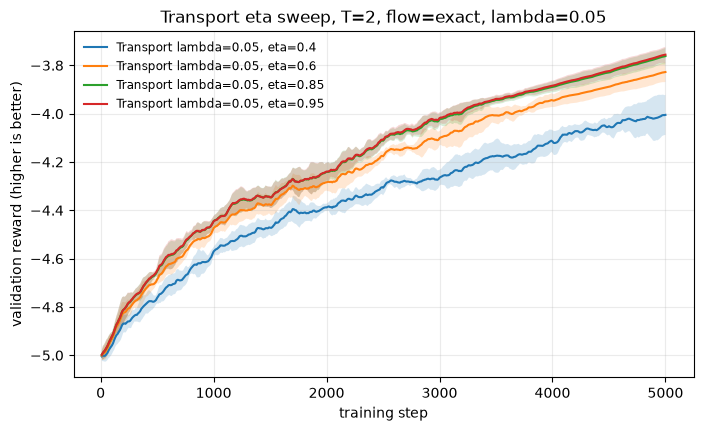

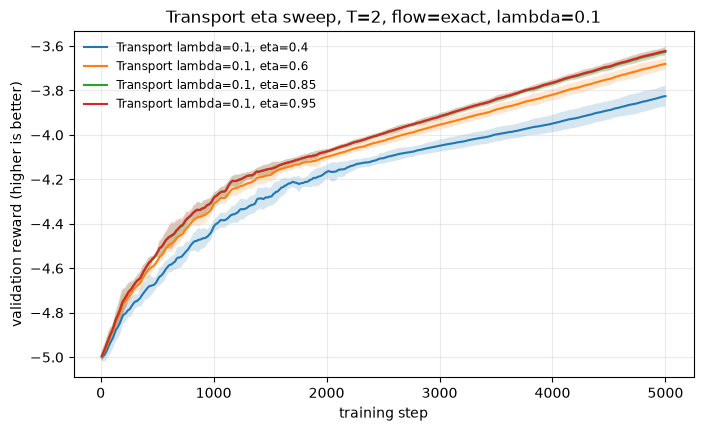

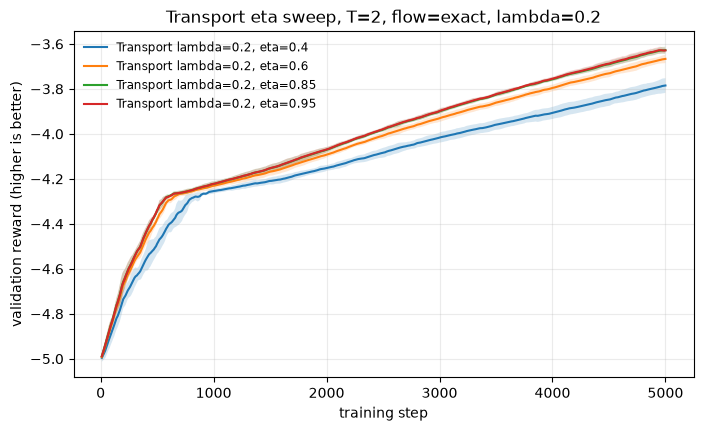

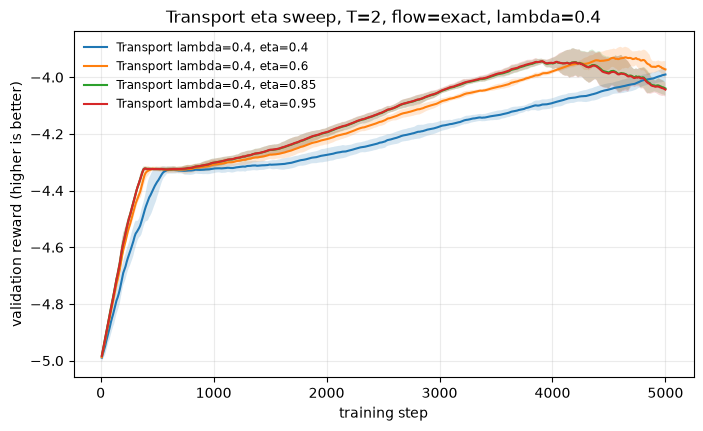

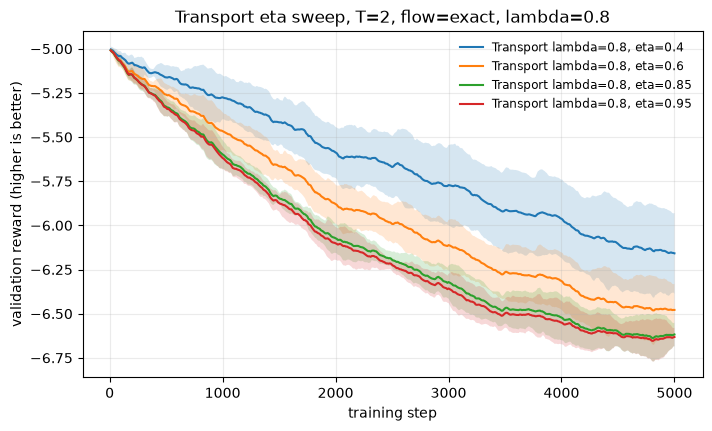

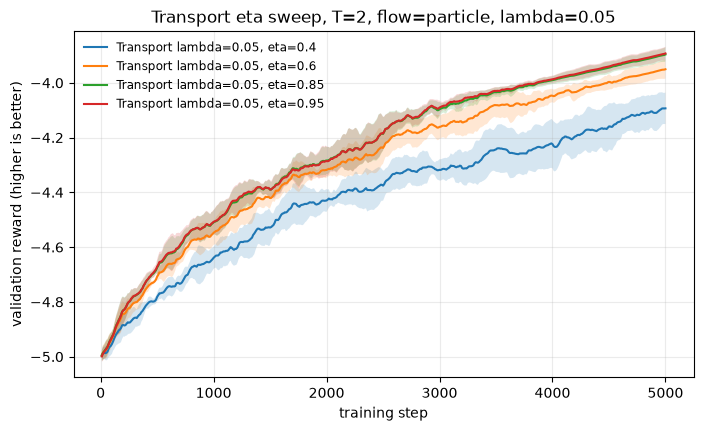

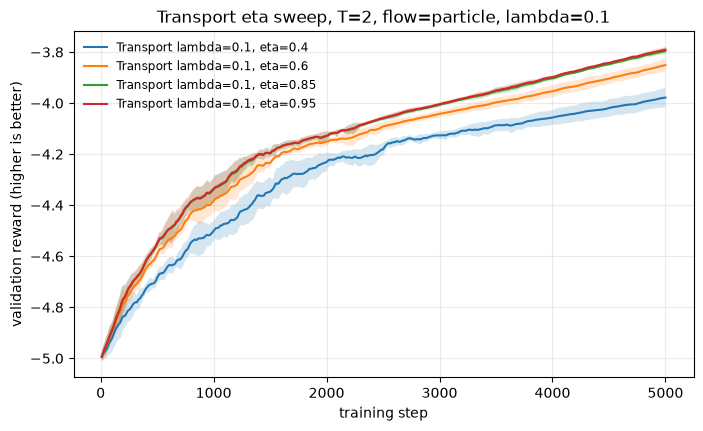

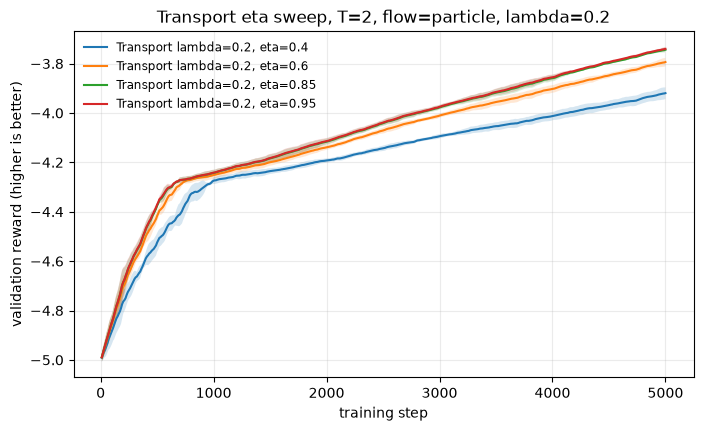

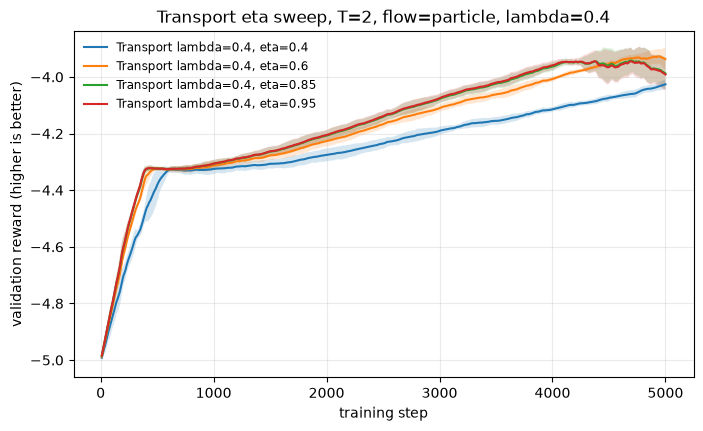

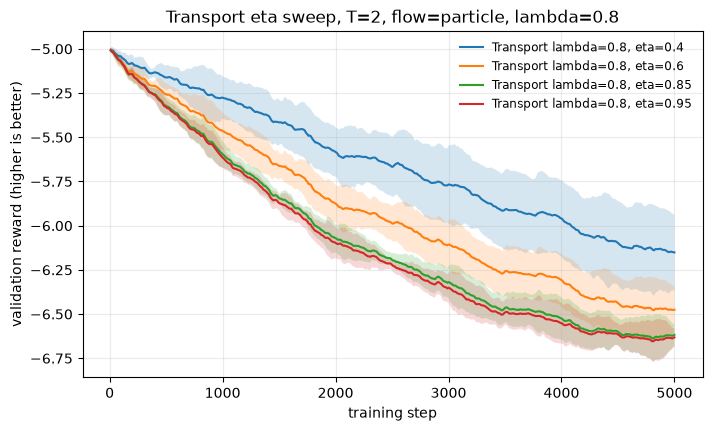

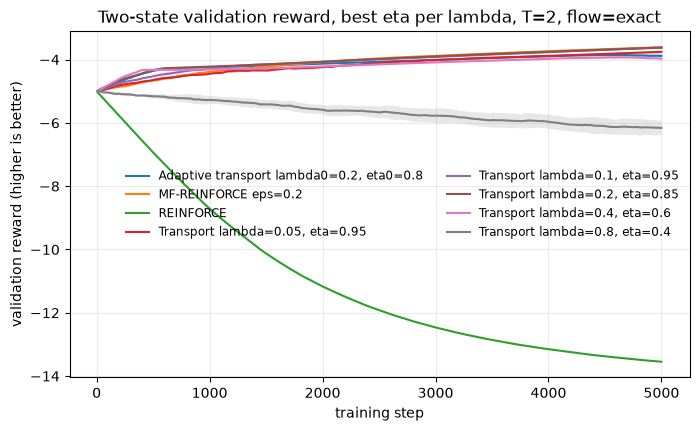

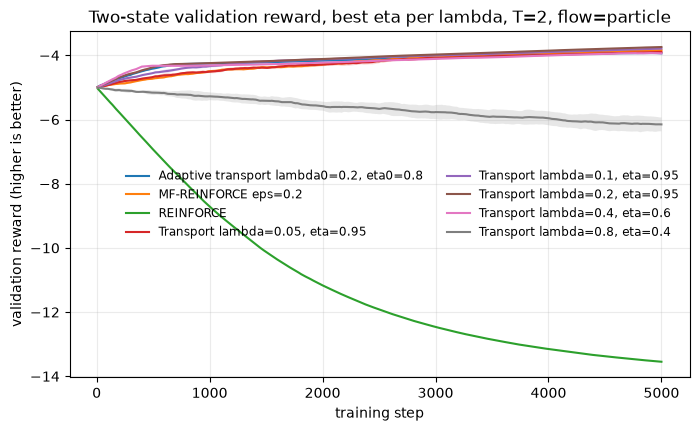

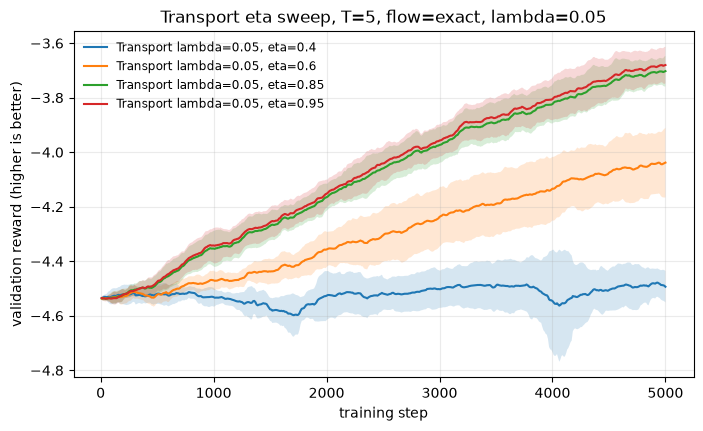

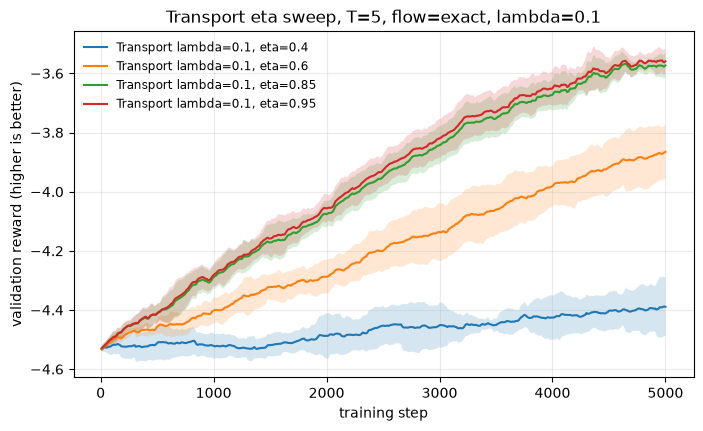

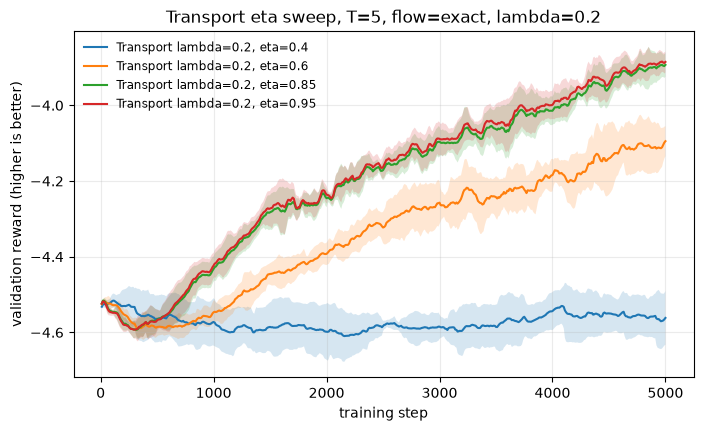

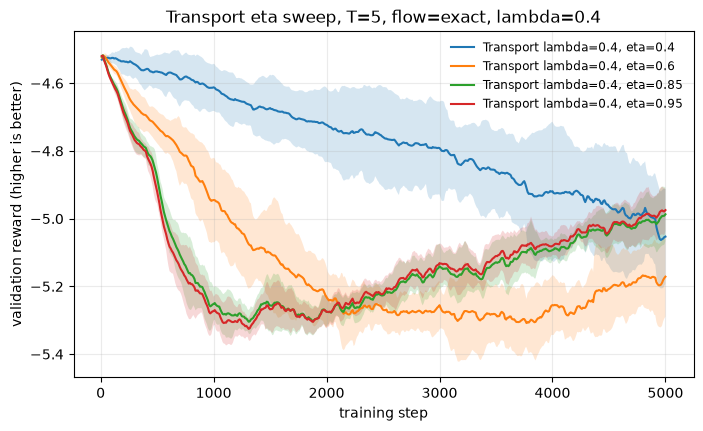

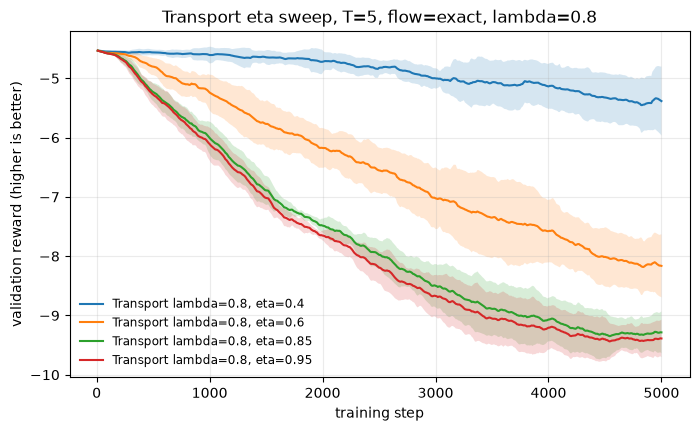

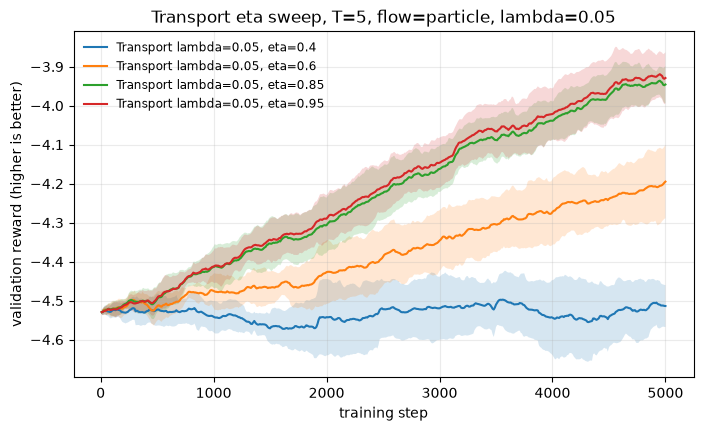

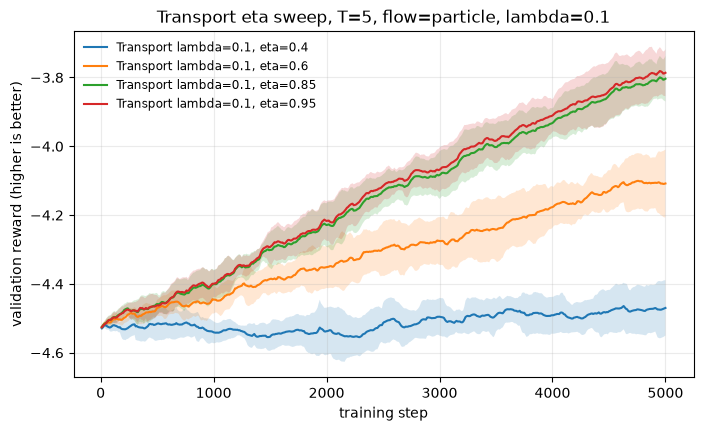

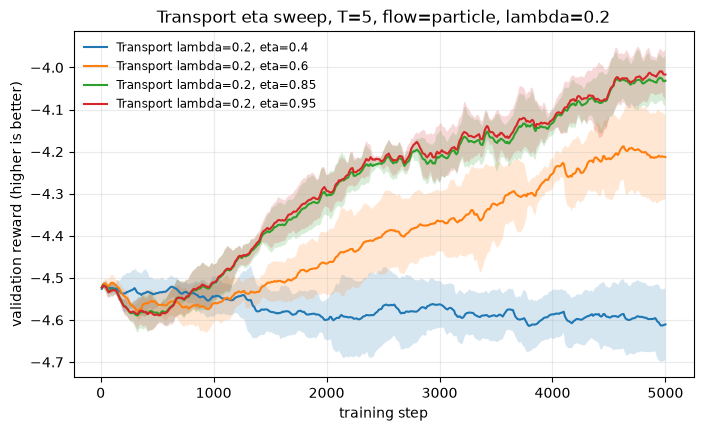

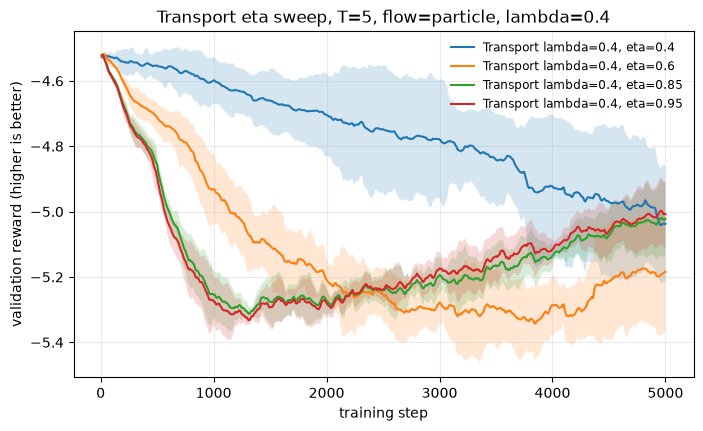

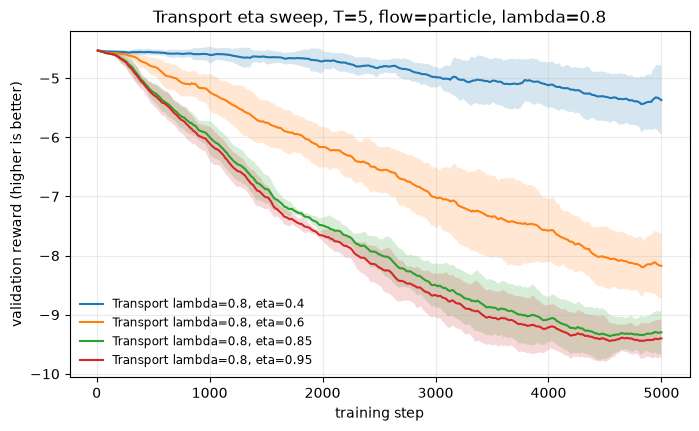

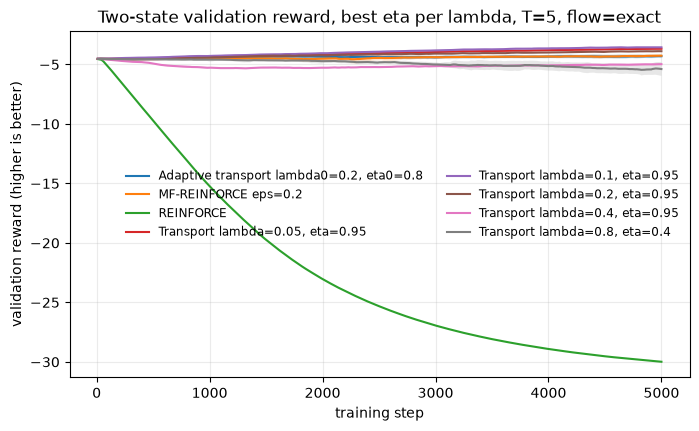

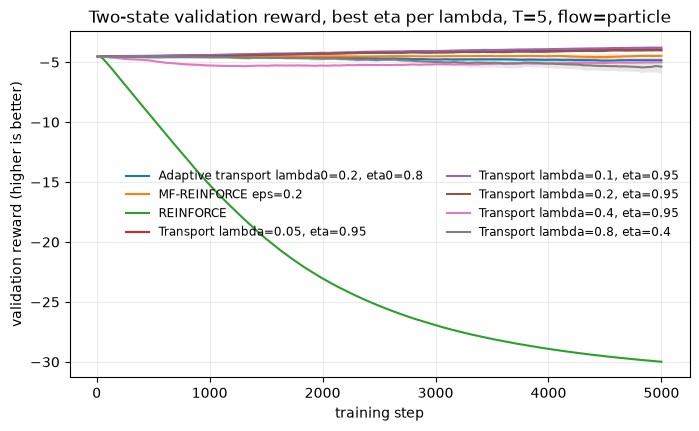

In [2]:
if not runs:
    print('No saved runs yet. Run scripts/run.py before executing the analysis cells.')
else:
    for horizon in sorted({run['metadata']['horizon'] for run in runs}):
        horizon_runs = [run for run in runs if run['metadata']['horizon'] == horizon]
        transport_flows = sorted({run['metadata']['flow'] for run in horizon_runs if run['metadata']['algorithm'] == 'transport'})

        for flow in transport_flows:
            transport_runs = [
                run
                for run in horizon_runs
                if run['metadata']['algorithm'] == 'transport' and run['metadata']['flow'] == flow
            ]
            for perturbation in sorted({run['metadata'].get('perturbation') for run in transport_runs}, key=_sort_key):
                lambda_runs = [run for run in transport_runs if run['metadata'].get('perturbation') == perturbation]
                if not lambda_runs:
                    continue
                fig, ax = plt.subplots(figsize=(8, 4.5))
                try:
                    plot_validation_rewards(lambda_runs, env=ENV, horizon=horizon, flow=flow, ax=ax)
                    ax.set_title(f'Transport eta sweep, T={horizon}, flow={flow}, lambda={perturbation:g}')
                    ax.legend(frameon=False, fontsize='small')
                    plt.show()
                except ValueError as exc:
                    plt.close(fig)
                    print(exc)

        for flow in transport_flows:
            overview_runs = compact_validation_runs(horizon_runs, flow)
            if not overview_runs:
                continue
            fig, ax = plt.subplots(figsize=(8, 4.5))
            try:
                plot_validation_rewards(overview_runs, env=ENV, horizon=horizon, ax=ax, show_flow_label=False)
                ax.set_title(f'Two-state validation reward, best eta per lambda, T={horizon}, flow={flow}')
                ax.legend(frameon=False, fontsize='small', ncols=2)
                plt.show()
            except ValueError as exc:
                plt.close(fig)
                print(exc)

## Learned Policy Error

Average and maximum absolute errors between the learned action probabilities and the closed-form optimal stationary policy.

In [3]:
policy_errors = twostate_policy_error_table(runs)
if policy_errors.empty:
    print('No two-state policy table available yet.')
else:
    display(policy_errors.groupby(['label', 'flow', 'horizon'], as_index=False).agg(
        mean_abs_policy_error=('mean_abs_policy_error', 'mean'),
        mean_abs_policy_error_std=('mean_abs_policy_error', 'std'),
        max_abs_policy_error=('max_abs_policy_error', 'mean'),
    ).fillna(0.0))

,label,flow,horizon,mean_abs_policy_error,mean_abs_policy_error_std,max_abs_policy_error
0,"Adaptive transport lambda0=0.2, eta0=0.8",exact,2,0.099716,0.010802,0.177573
1,"Adaptive transport lambda0=0.2, eta0=0.8",exact,5,0.123046,0.005957,0.178311
2,"Adaptive transport lambda0=0.2, eta0=0.8",particle,2,0.123244,0.011707,0.214227
3,"Adaptive transport lambda0=0.2, eta0=0.8",particle,5,0.162977,0.006382,0.233561
4,MF-REINFORCE eps=0.2,exact,2,0.053925,0.003336,0.064798
...,...,...,...,...,...,...
85,"Transport lambda=0.8, eta=0.85",particle,5,0.290522,0.009094,0.370831
86,"Transport lambda=0.8, eta=0.95",exact,2,0.270191,0.011521,0.344897
87,"Transport lambda=0.8, eta=0.95",exact,5,0.292625,0.009012,0.373868
88,"Transport lambda=0.8, eta=0.95",particle,2,0.269744,0.011652,0.344703


## Learned State Flows

State-probability trajectories induced by the best saved policy for each algorithm, perturbation, horizon, and flow setting.

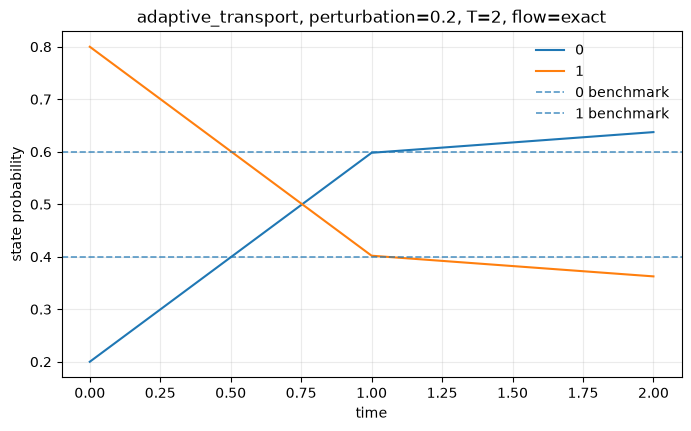

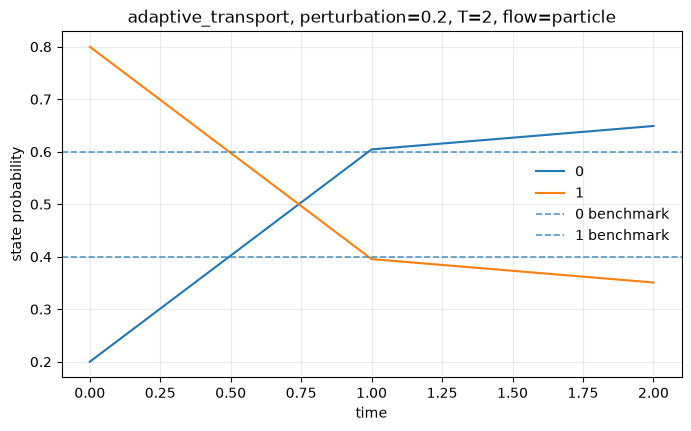

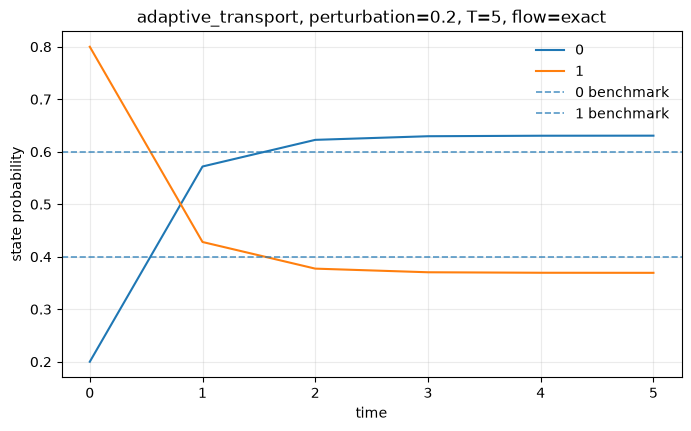

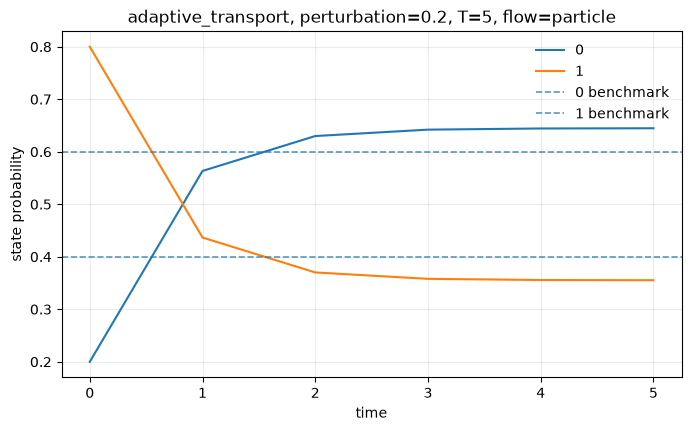

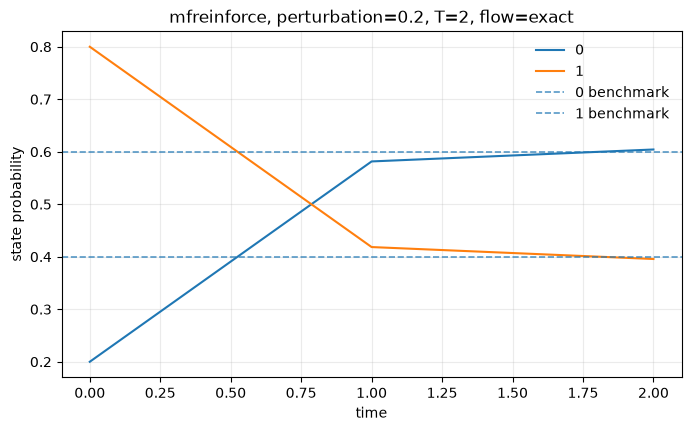

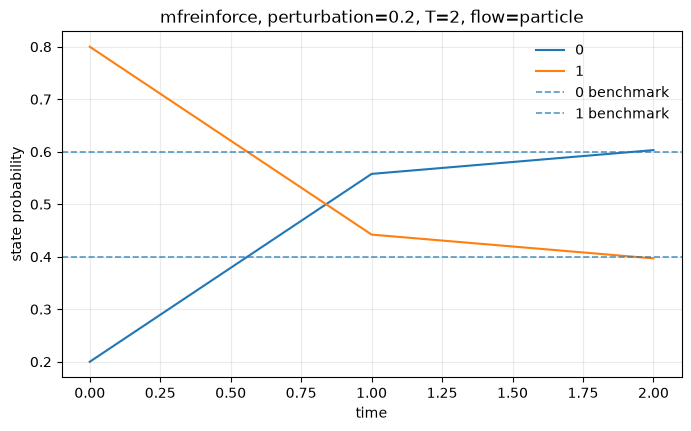

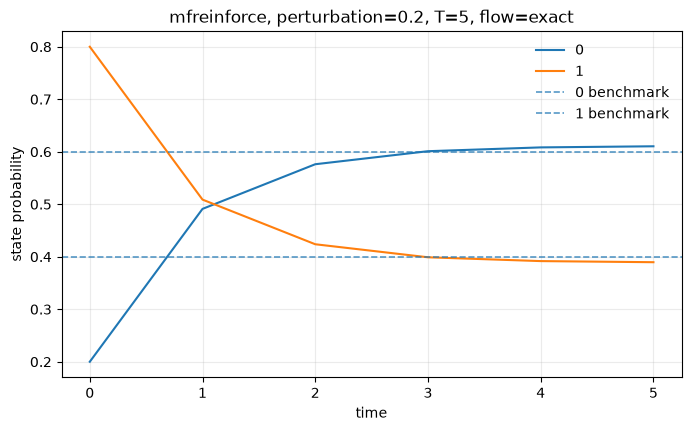

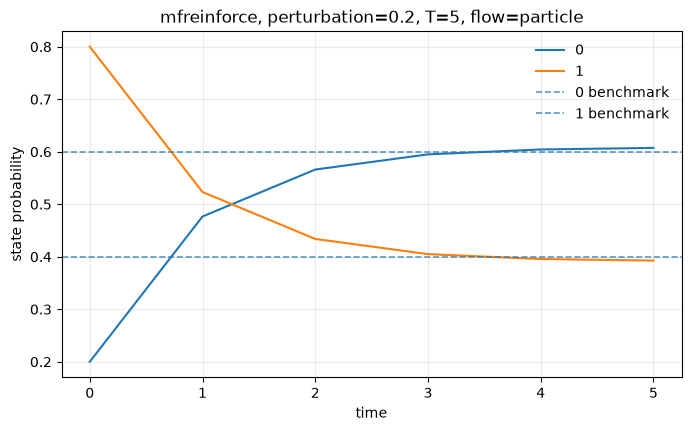

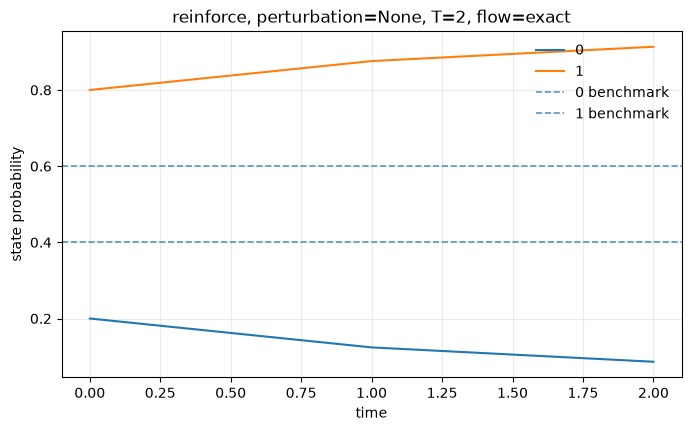

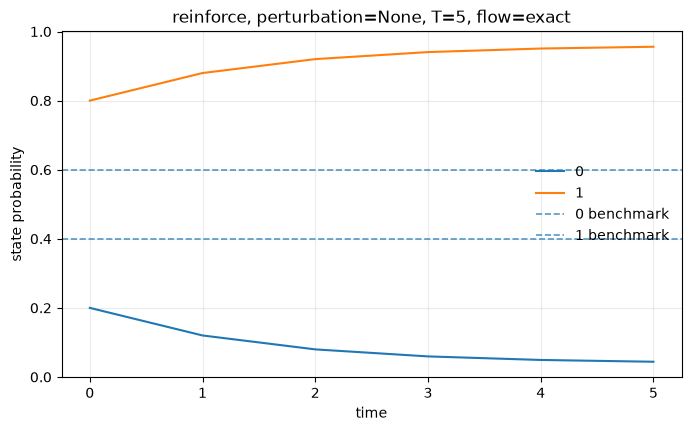

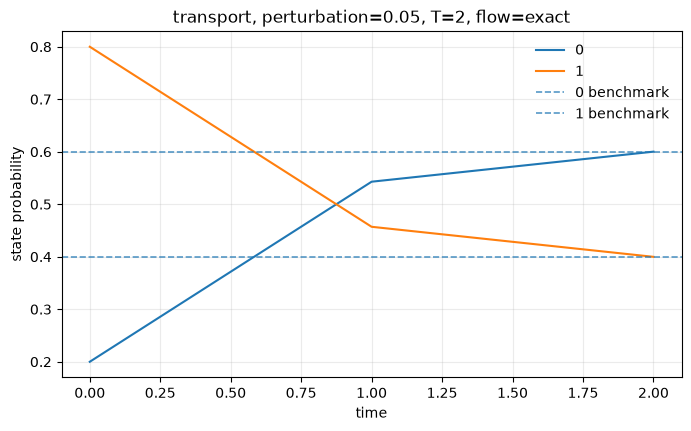

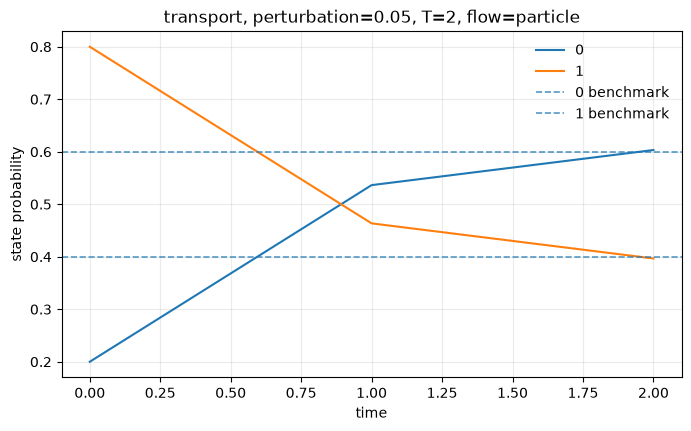

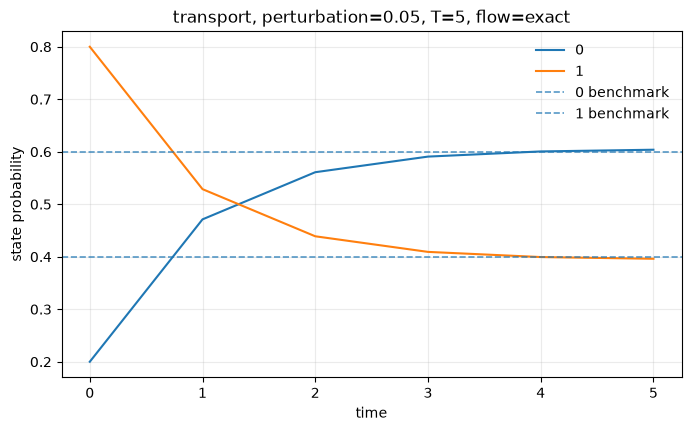

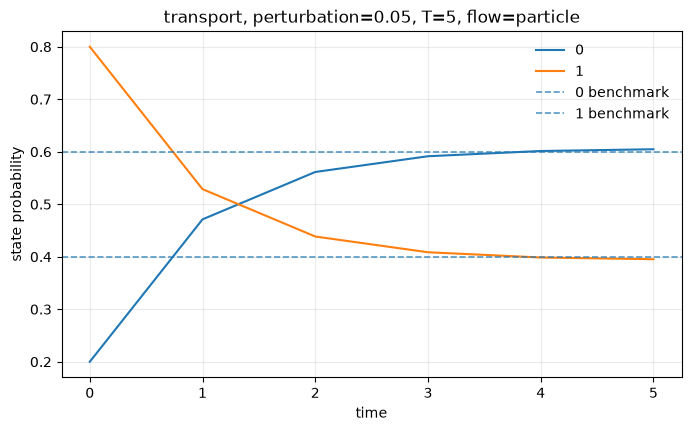

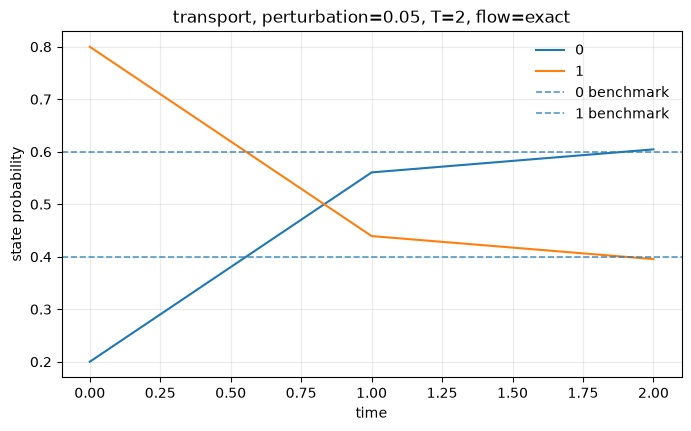

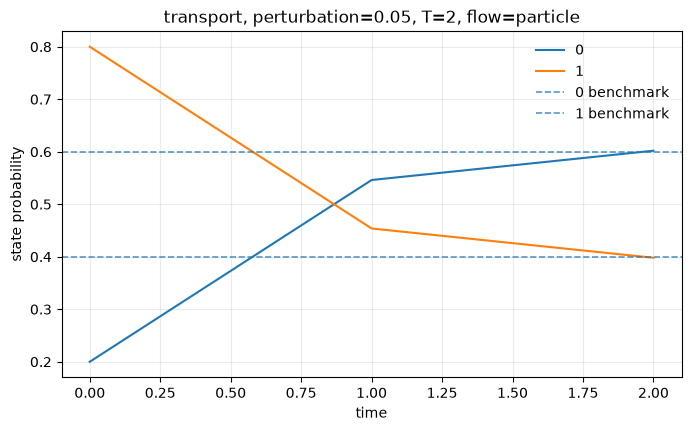

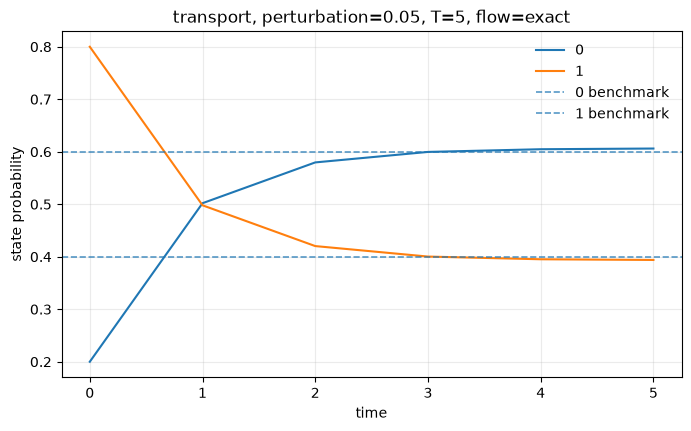

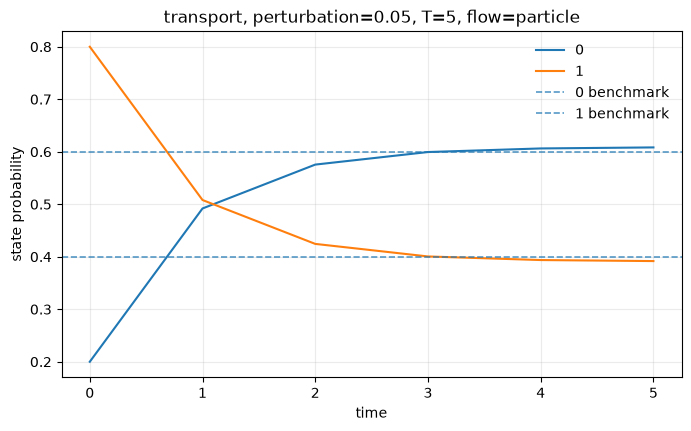

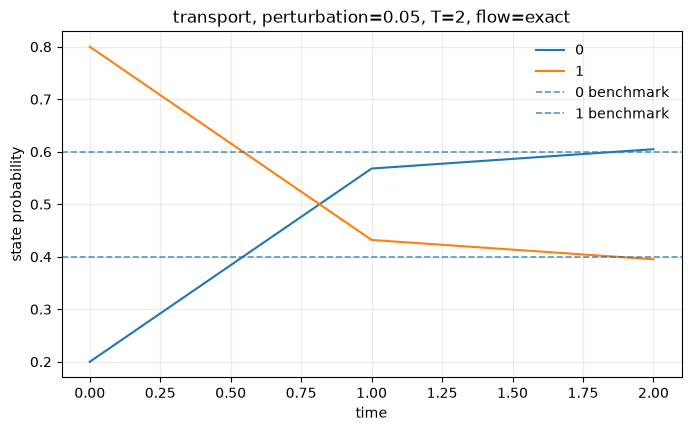

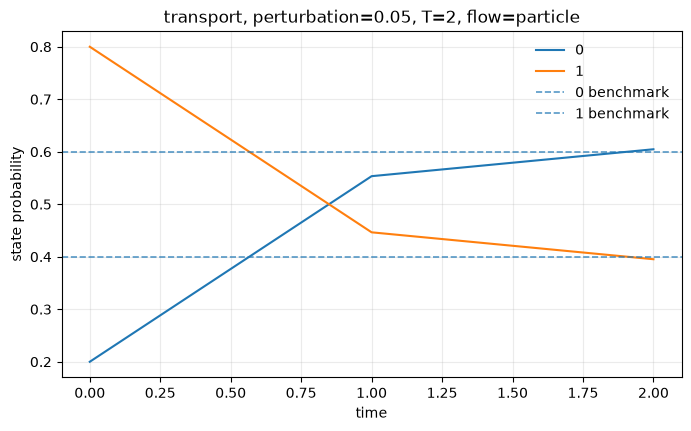

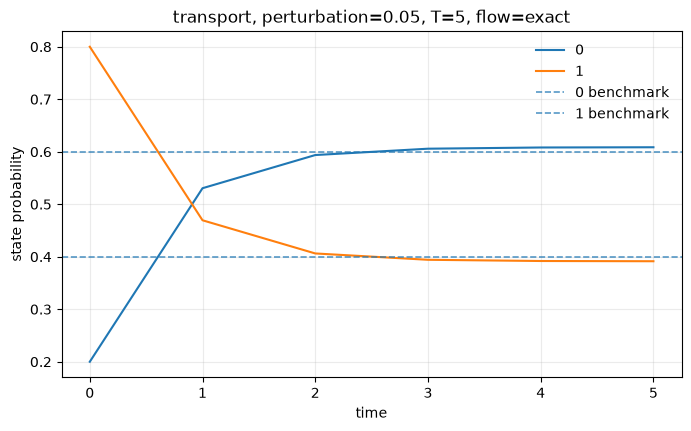

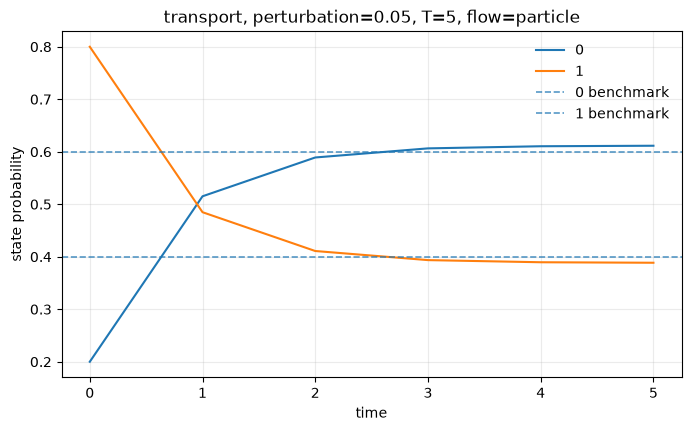

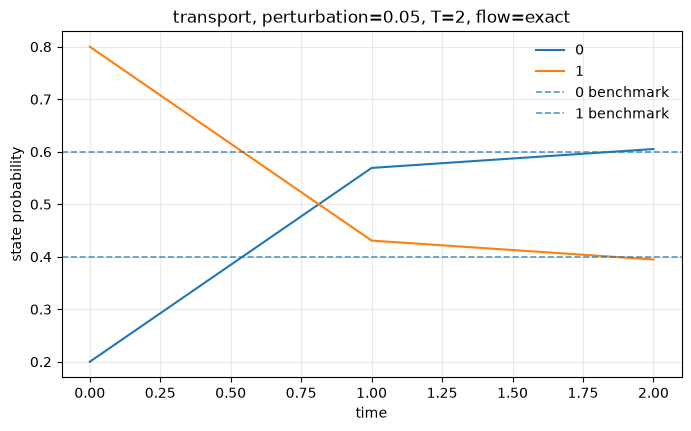

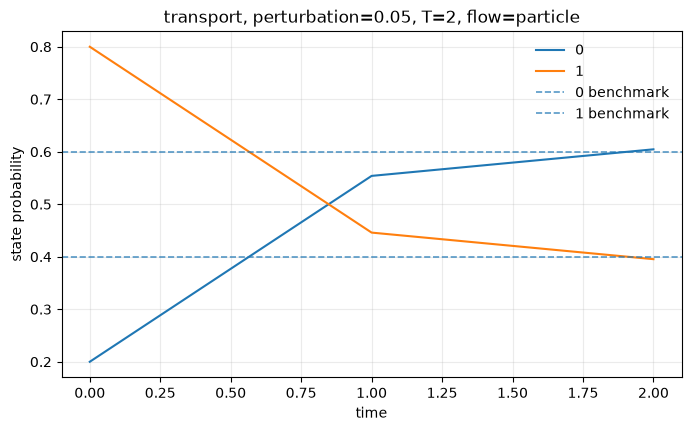

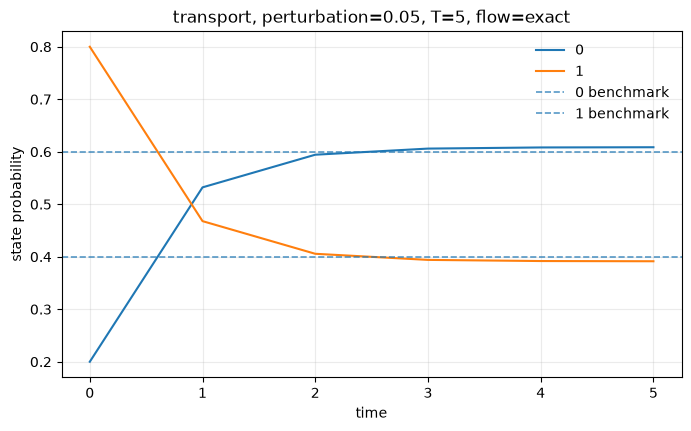

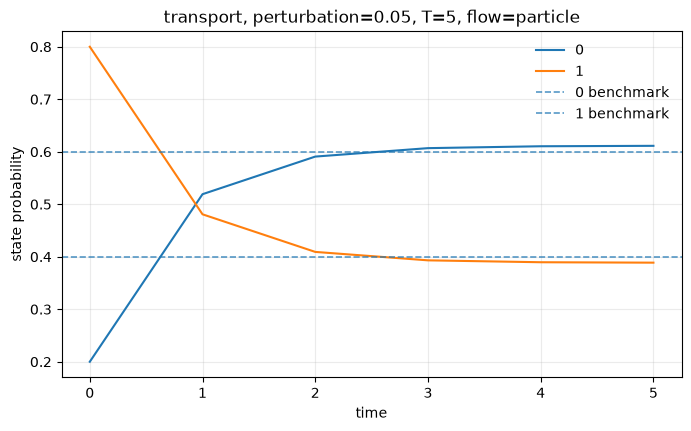

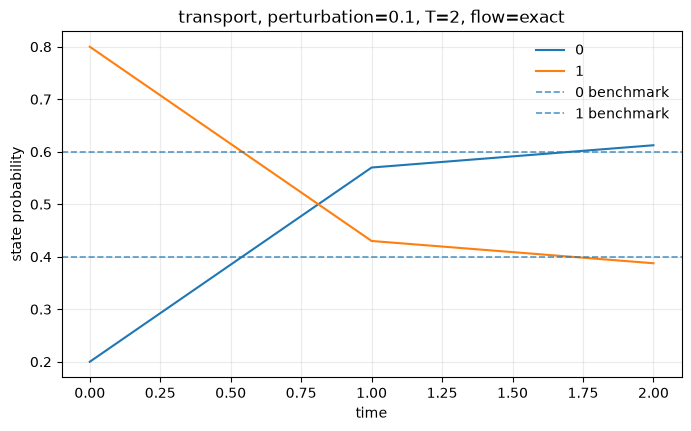

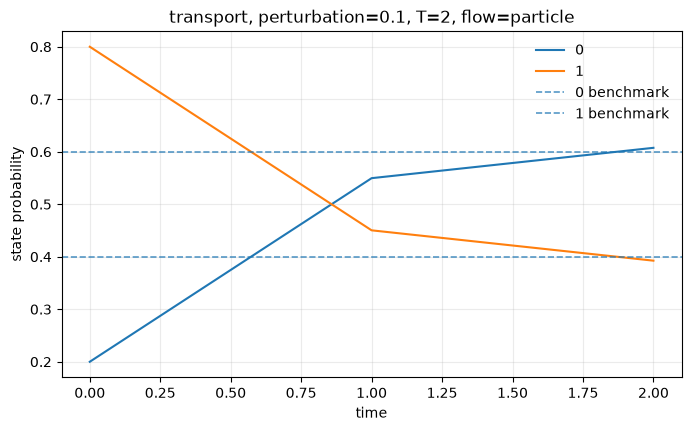

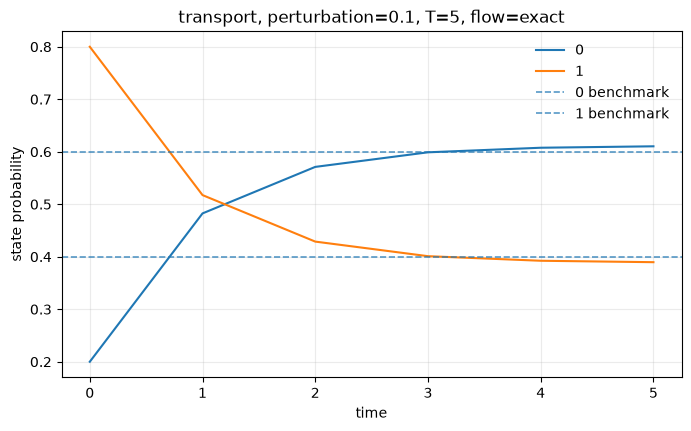

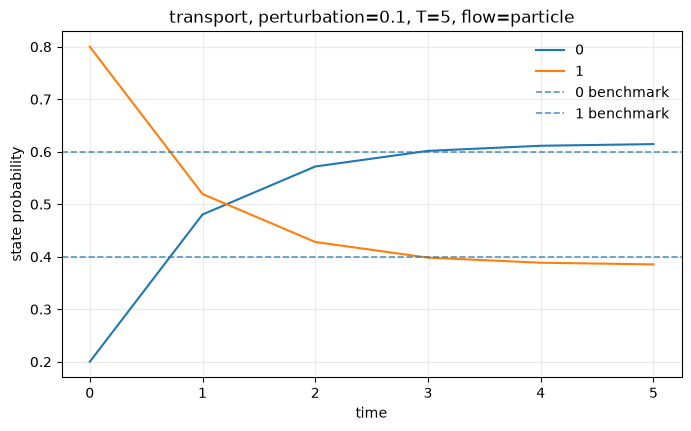

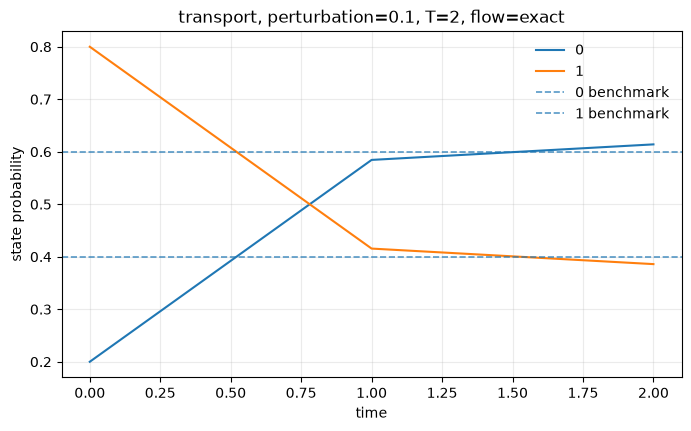

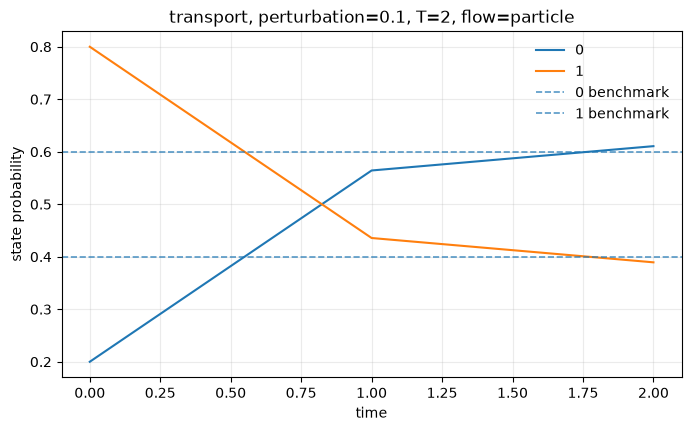

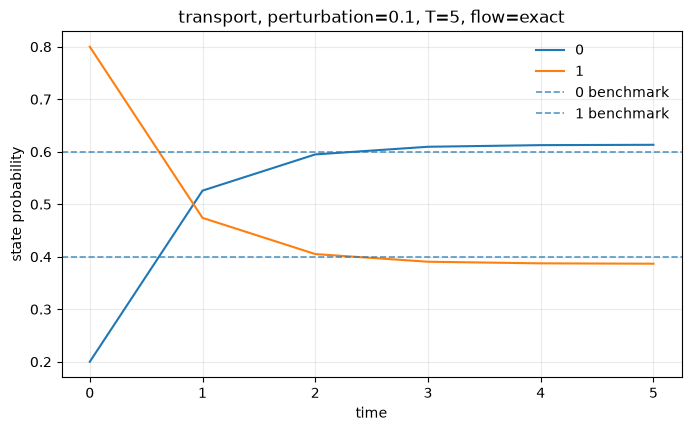

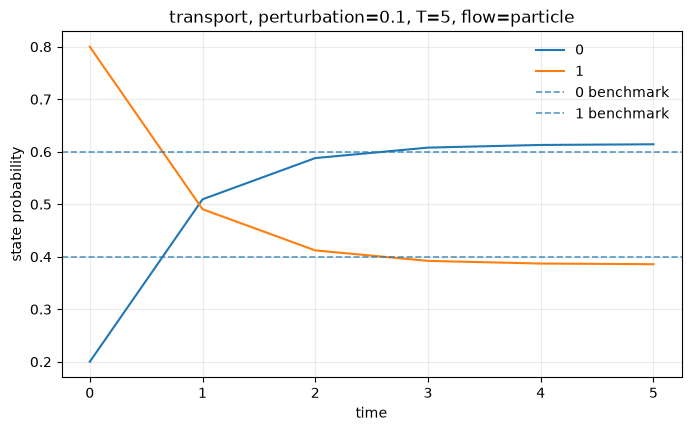

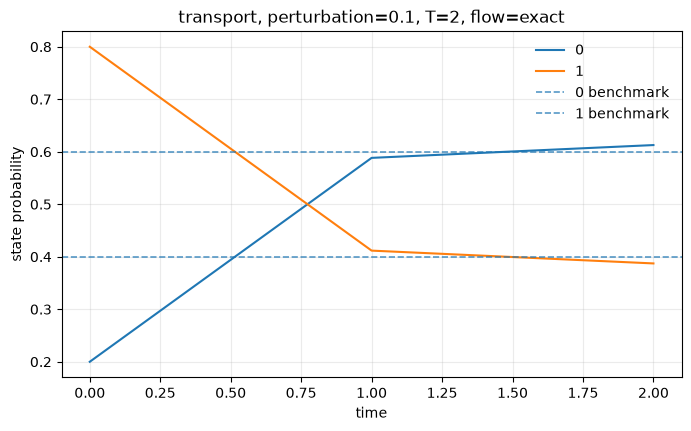

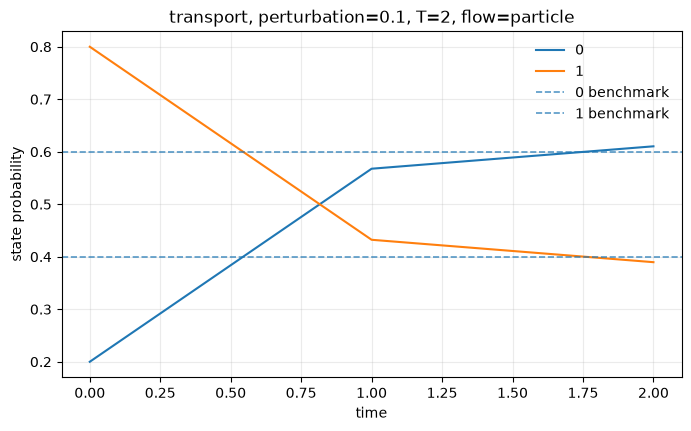

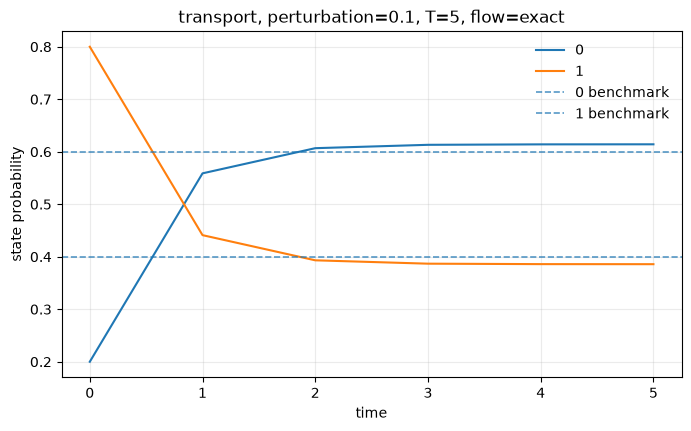

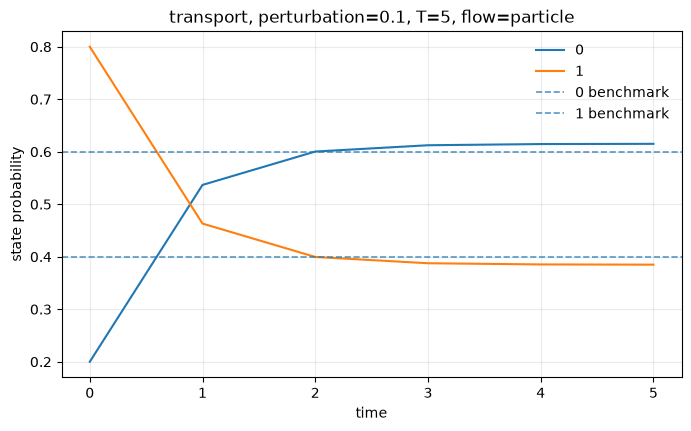

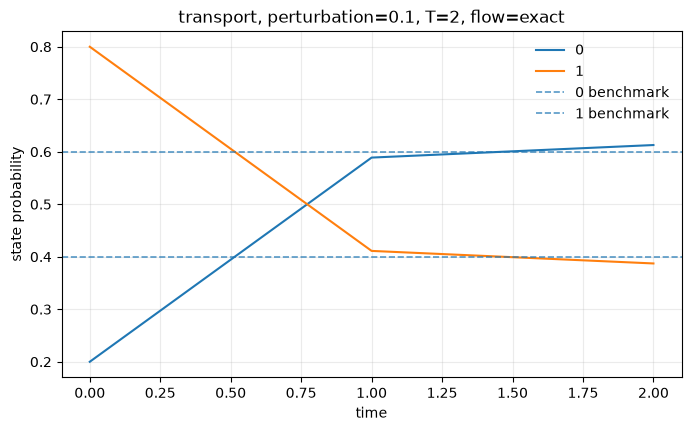

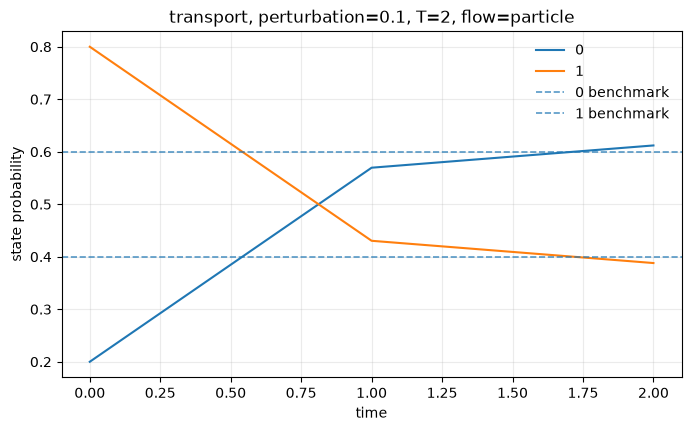

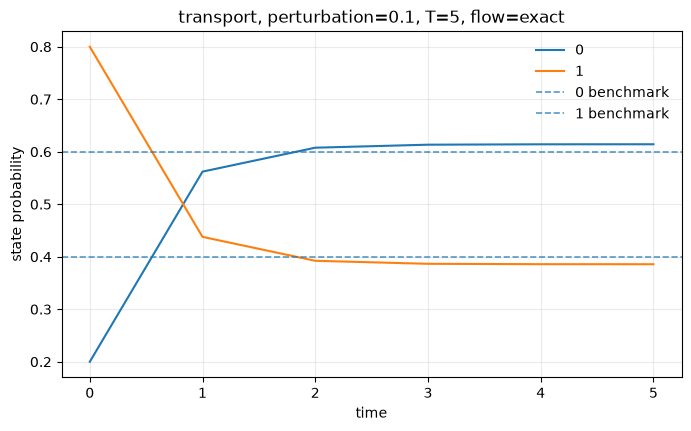

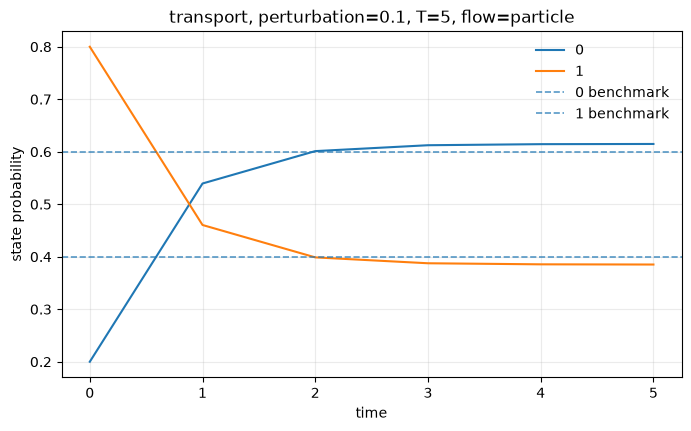

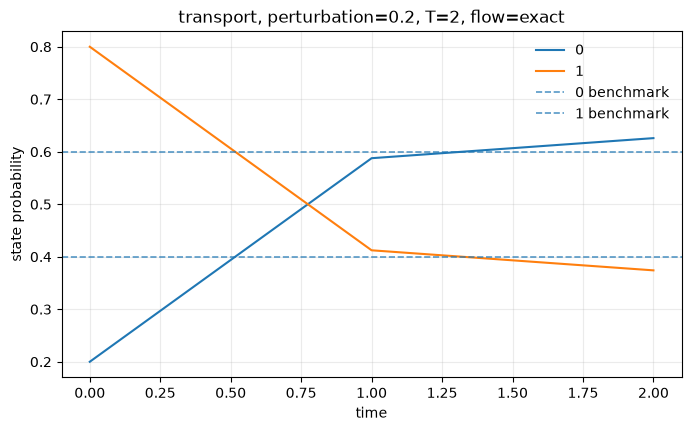

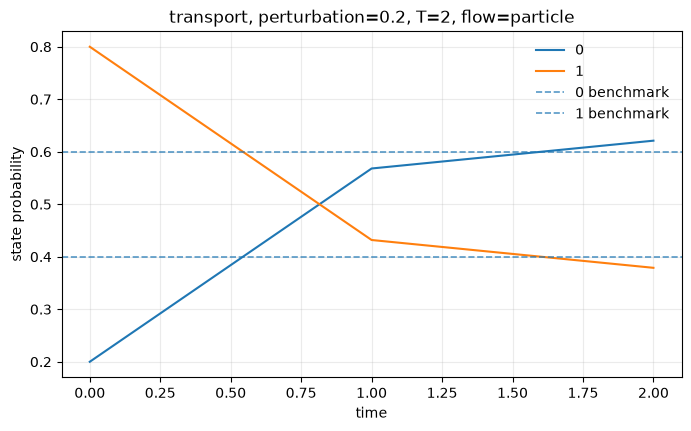

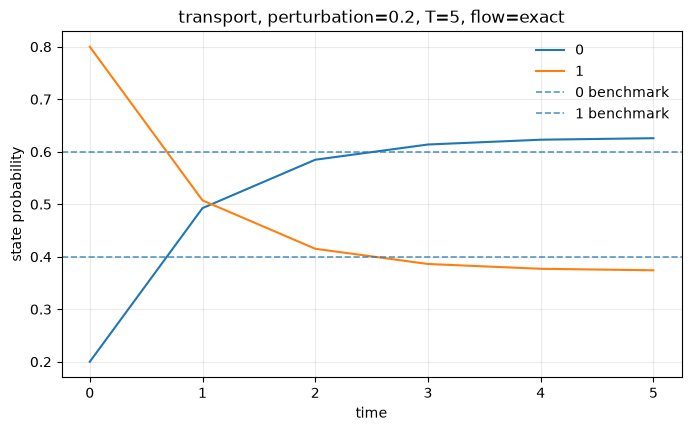

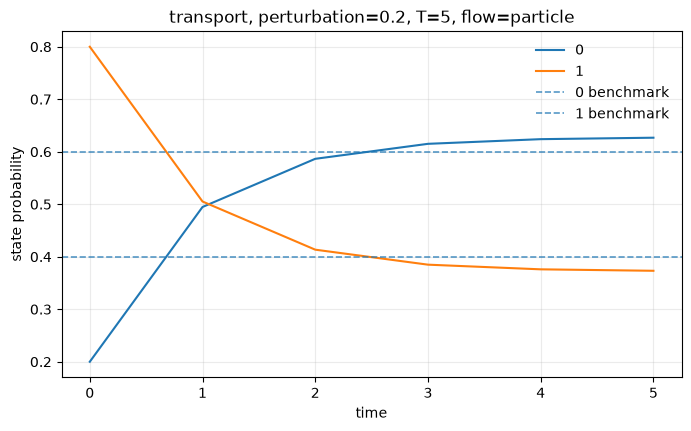

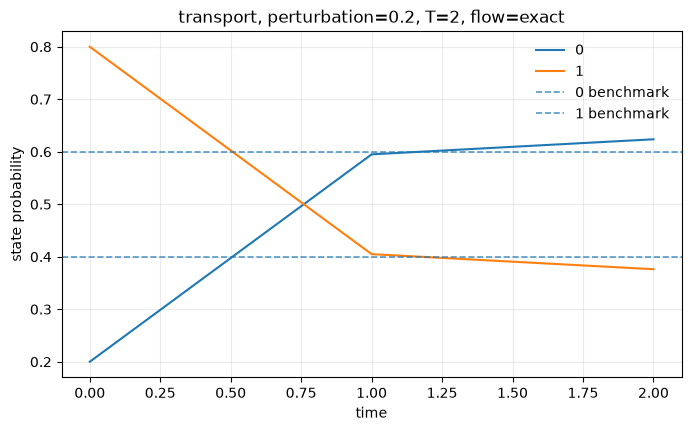

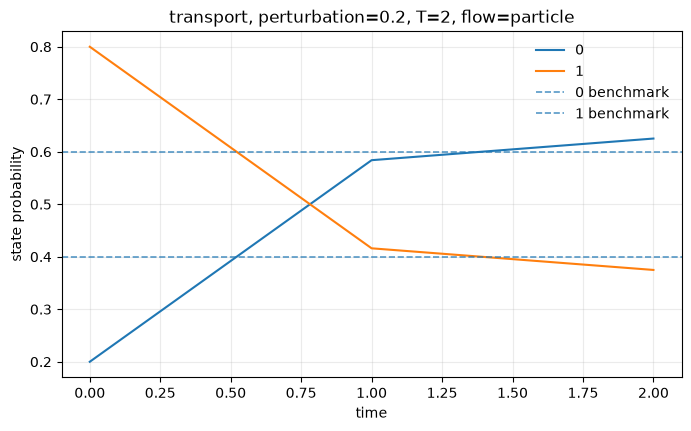

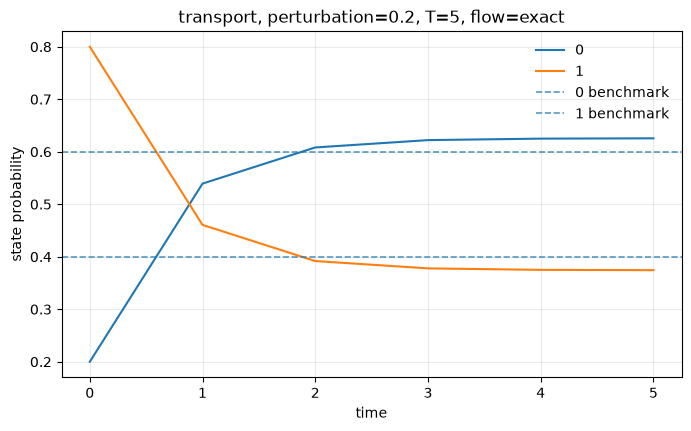

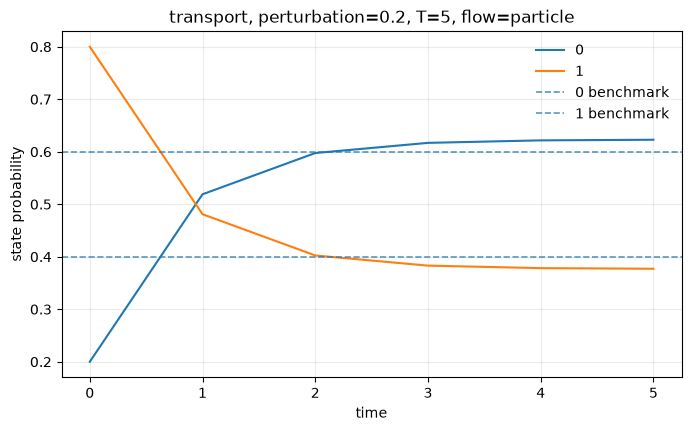

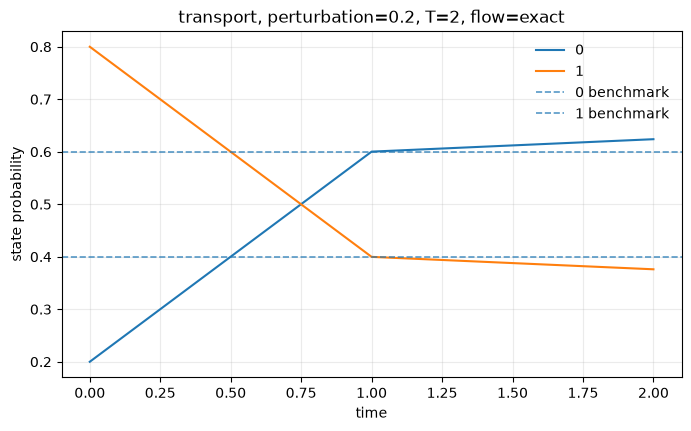

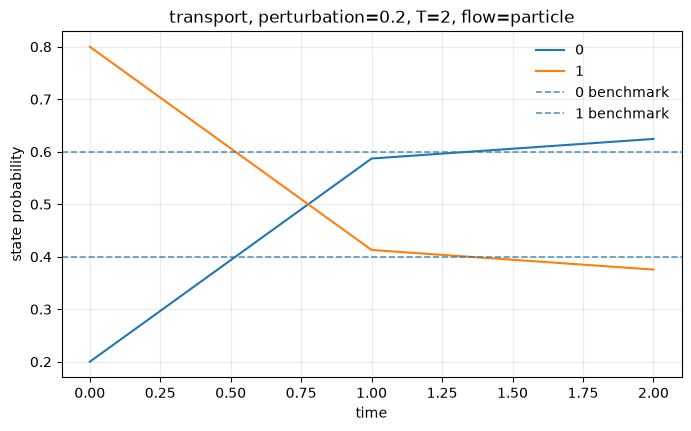

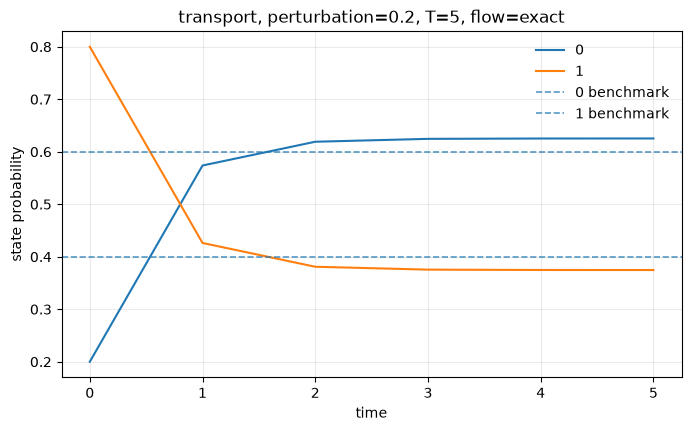

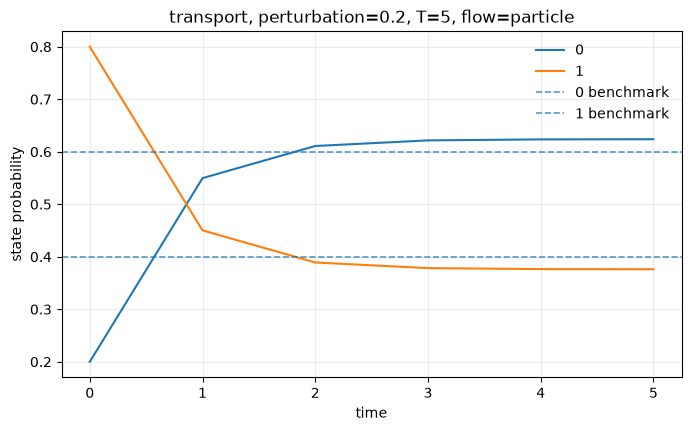

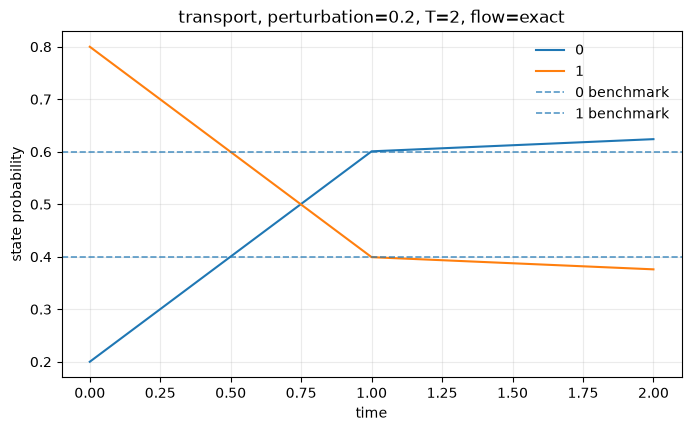

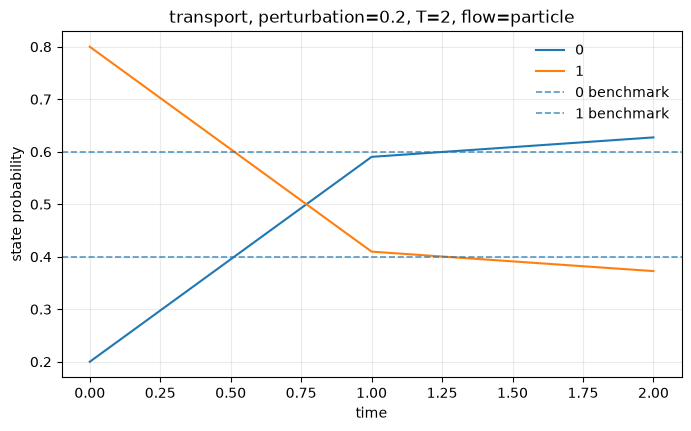

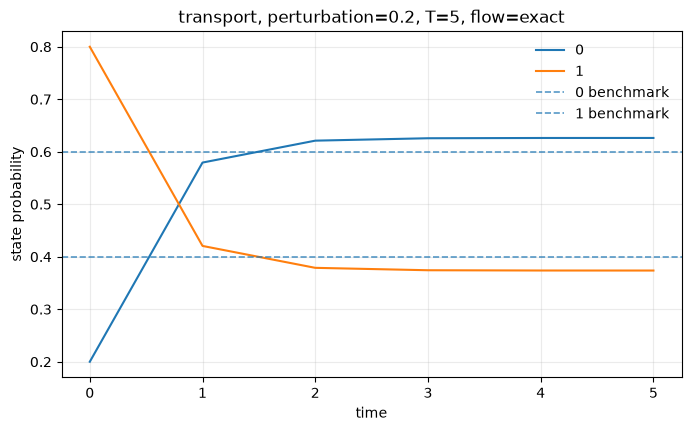

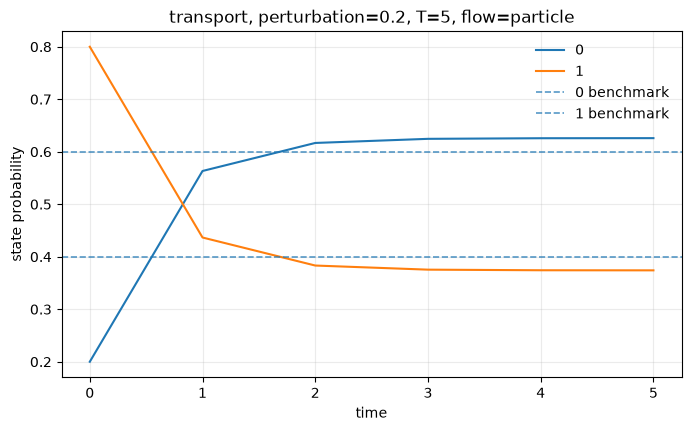

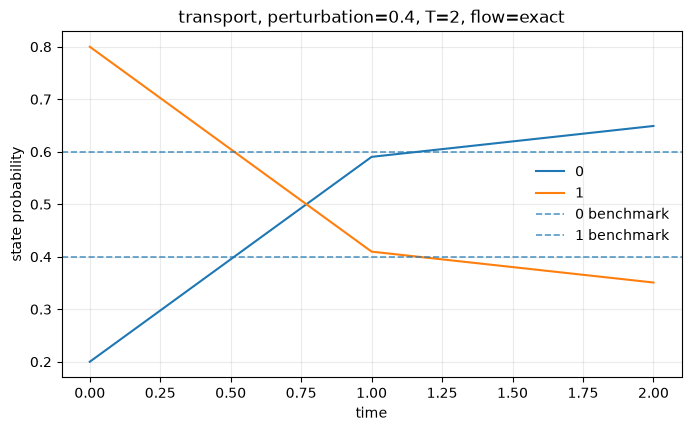

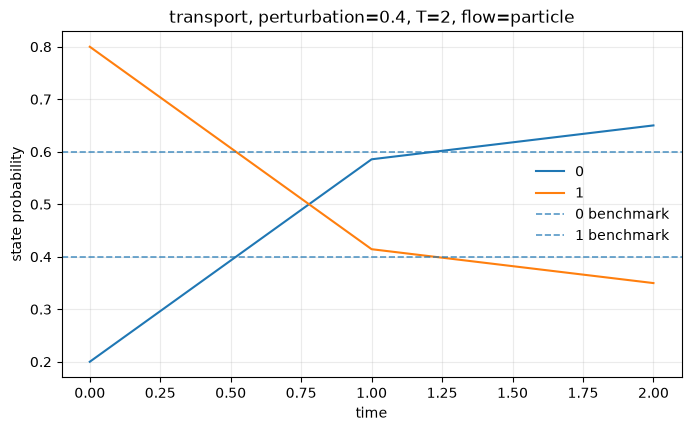

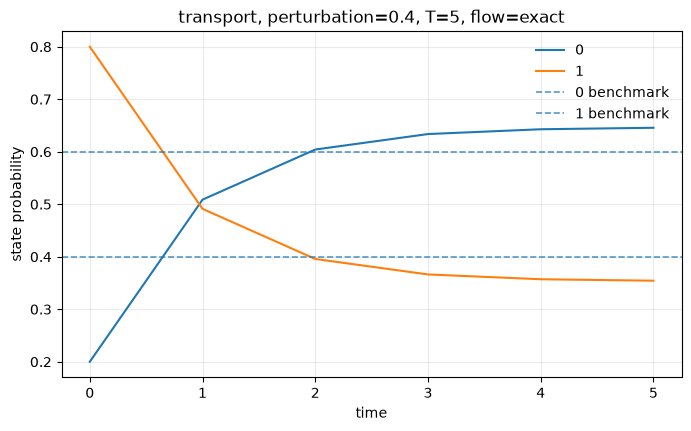

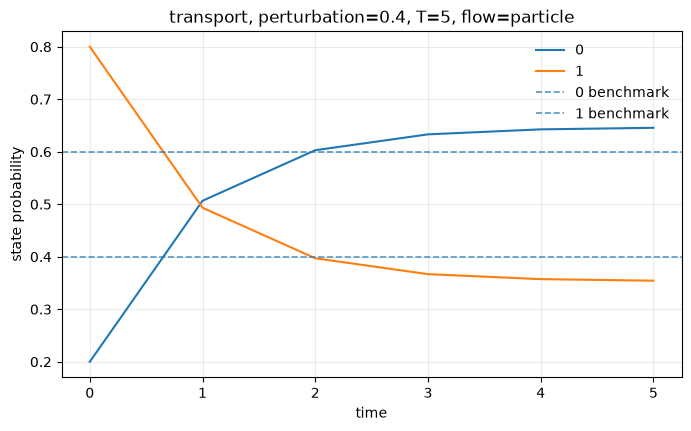

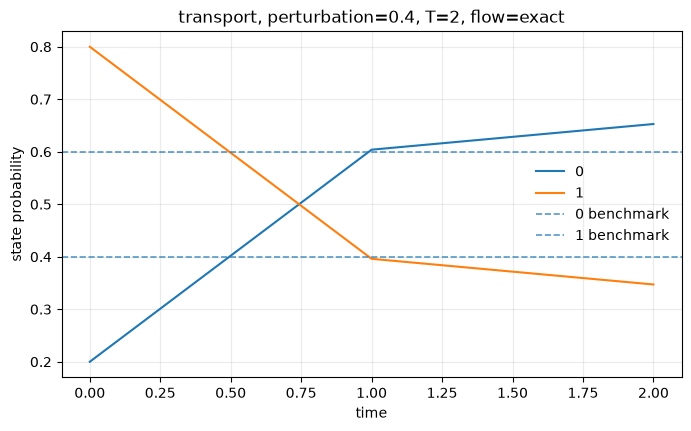

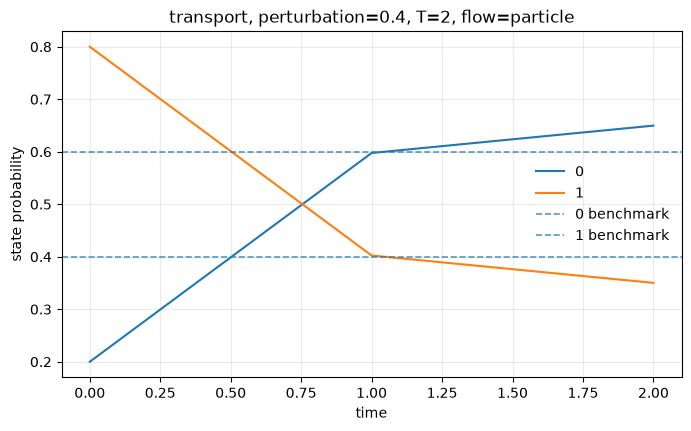

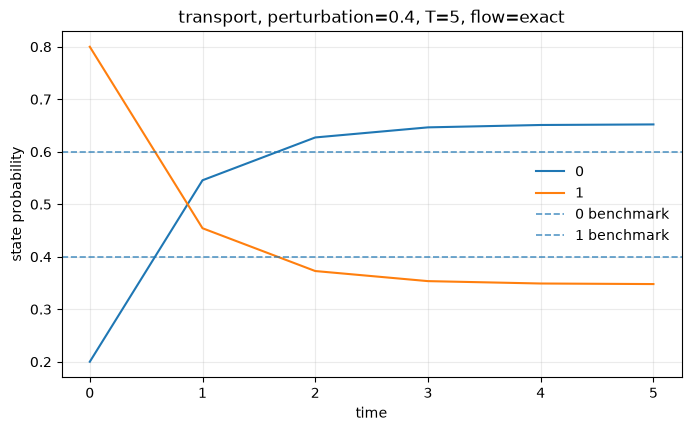

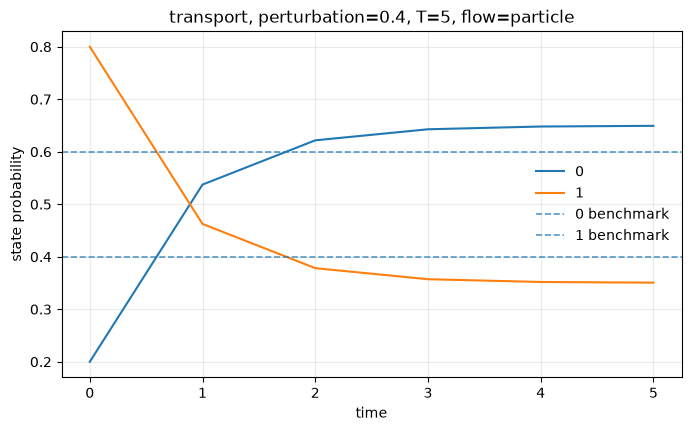

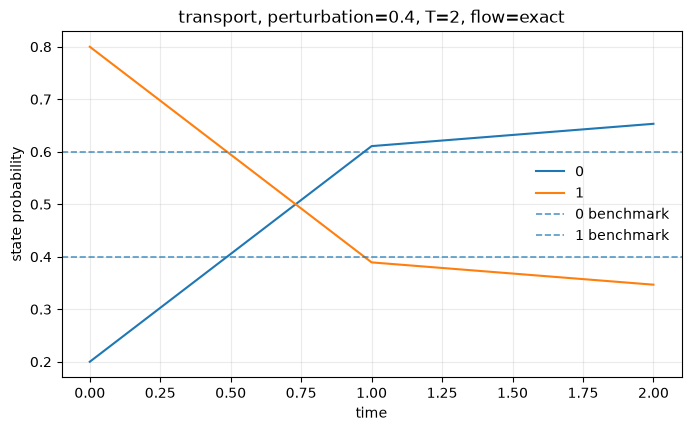

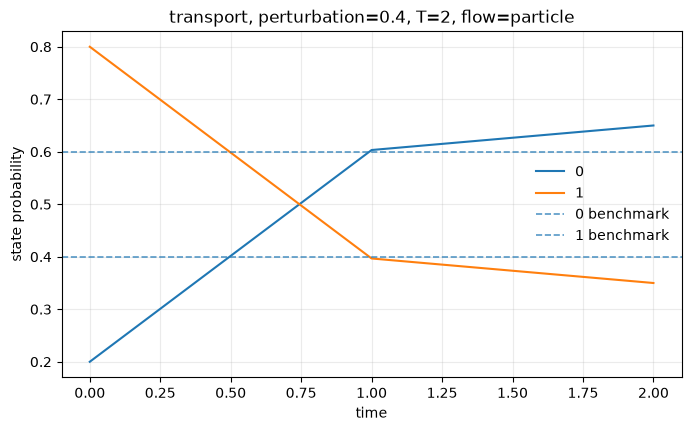

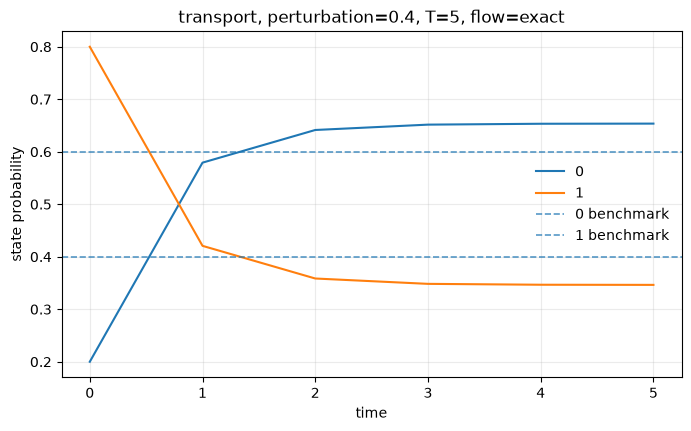

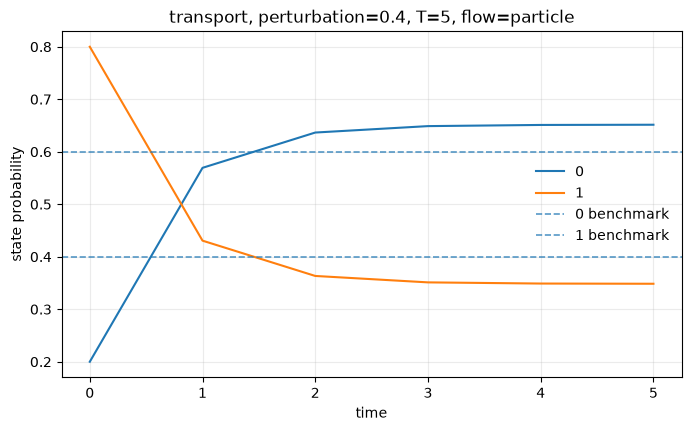

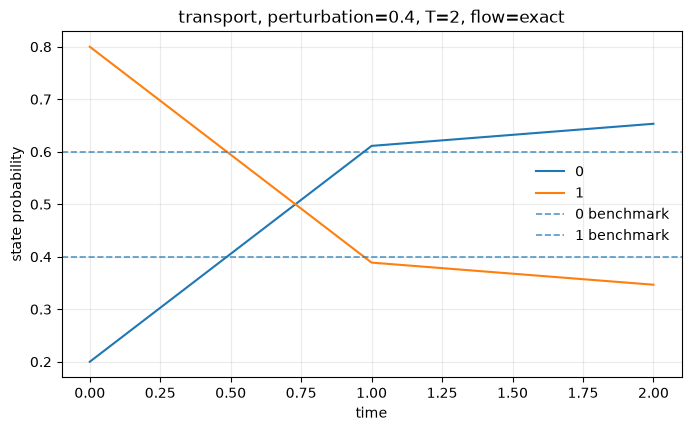

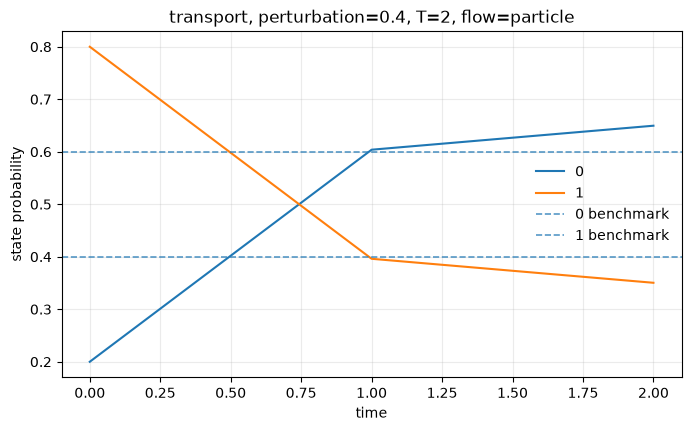

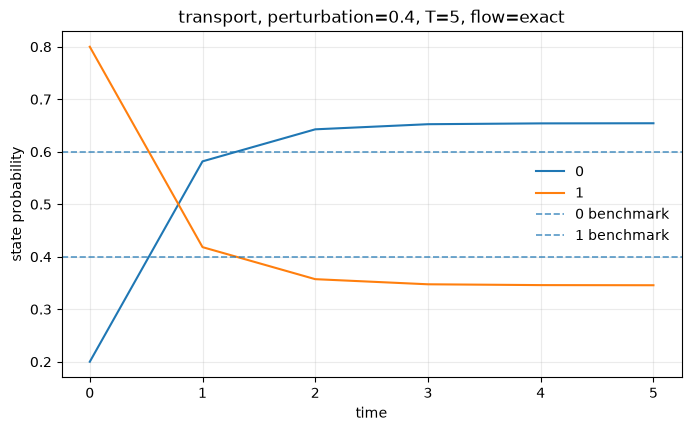

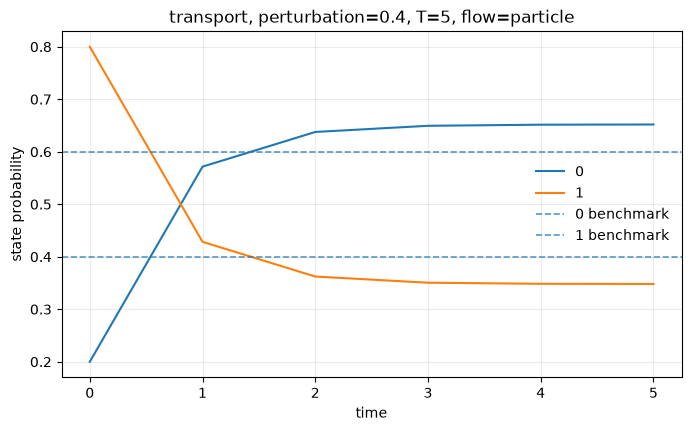

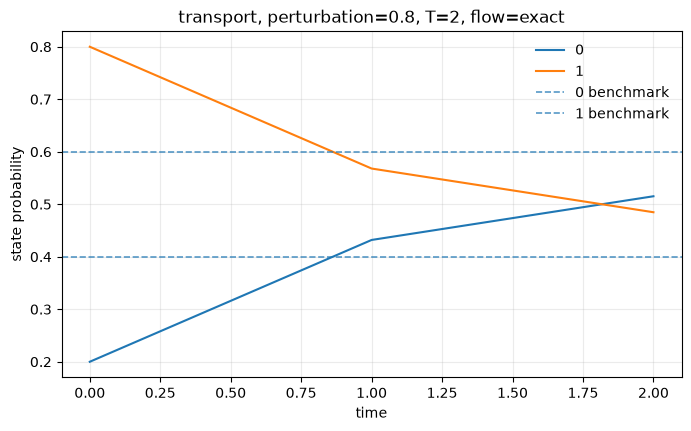

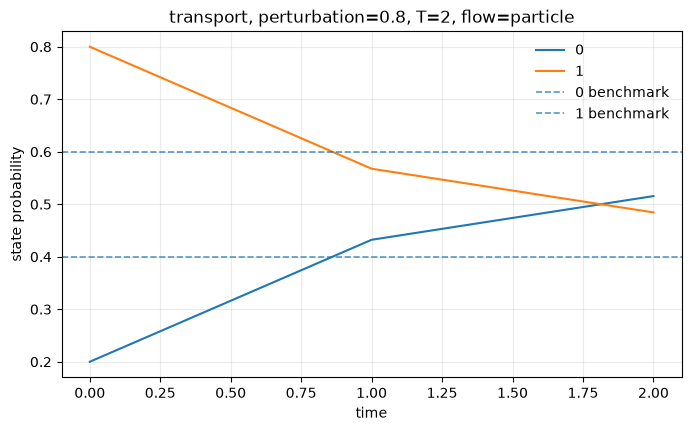

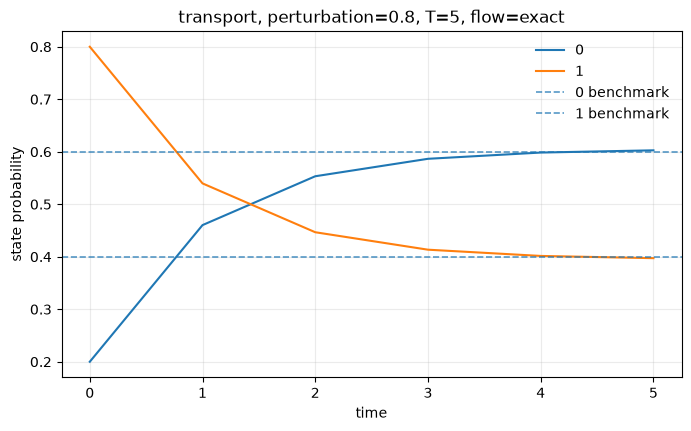

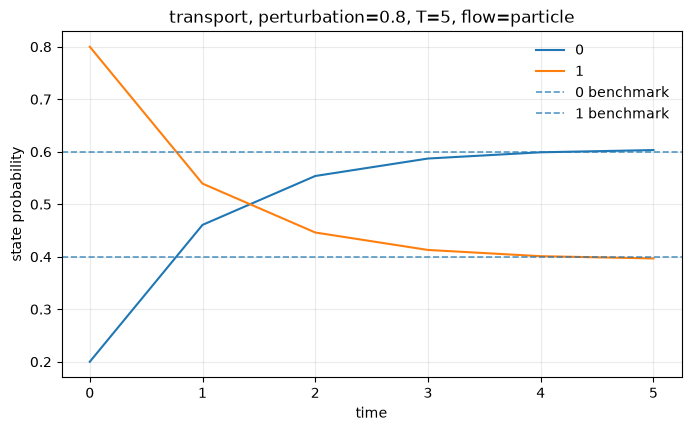

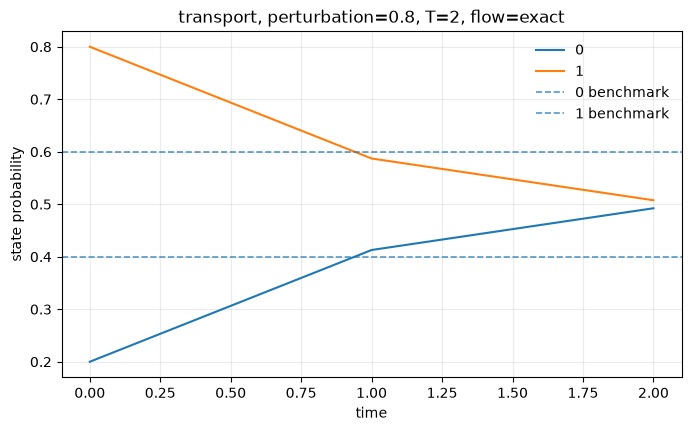

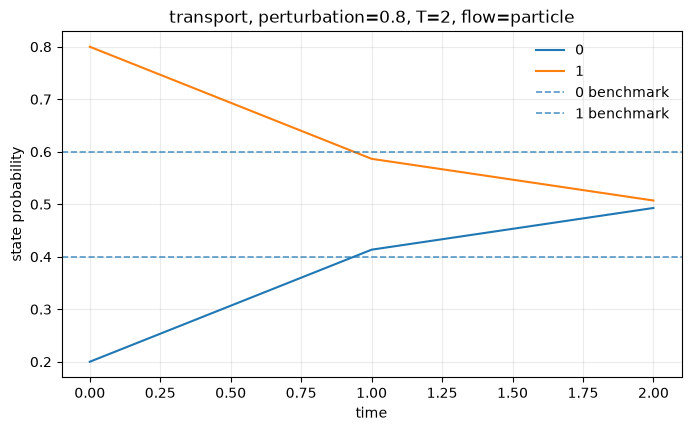

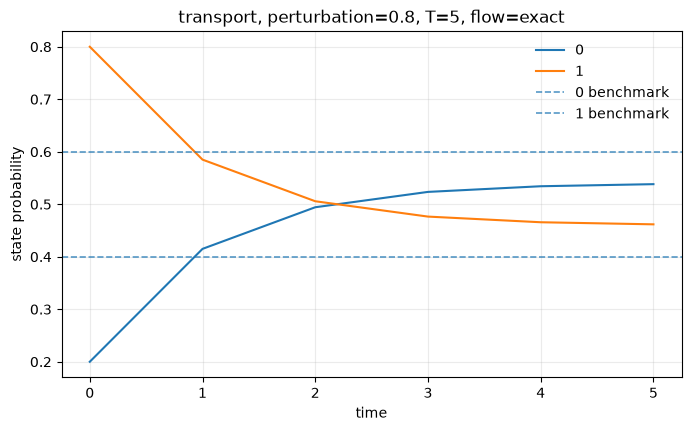

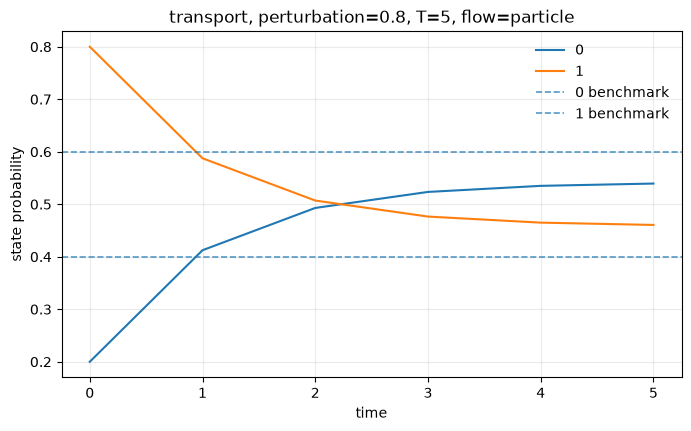

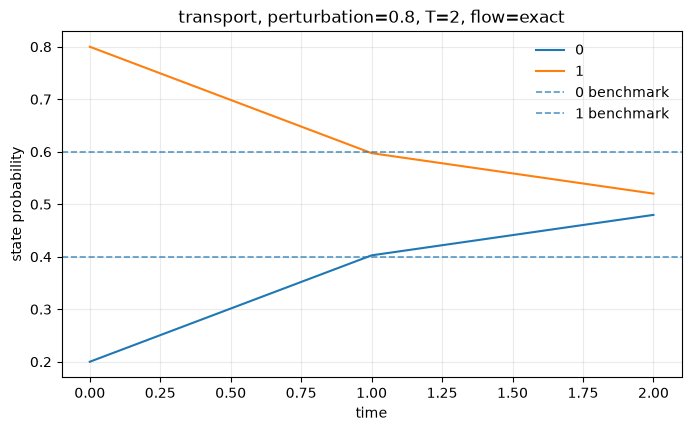

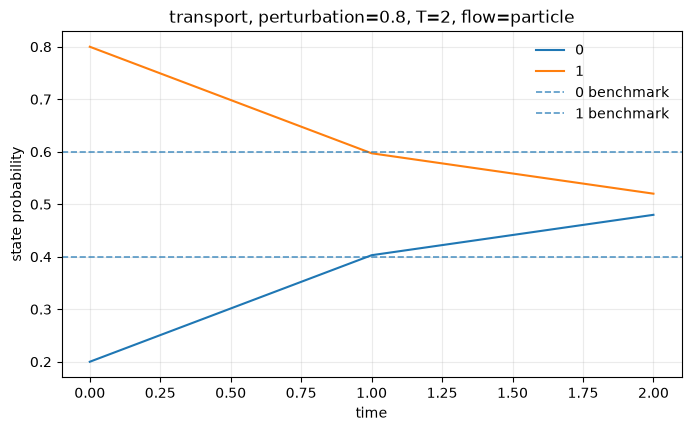

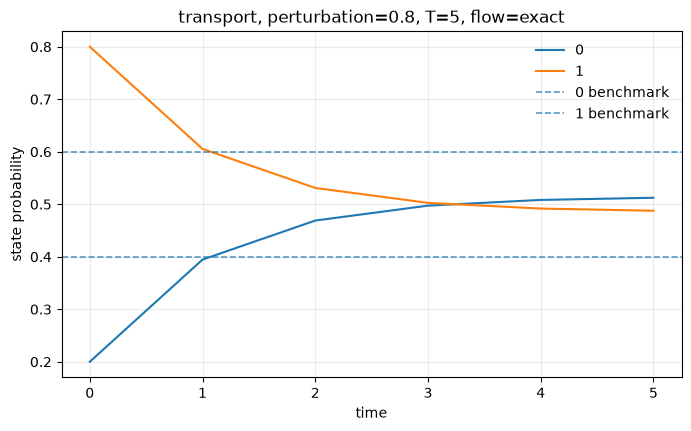

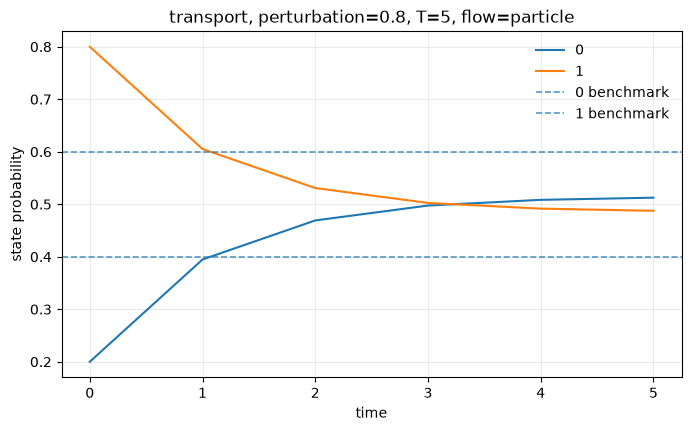

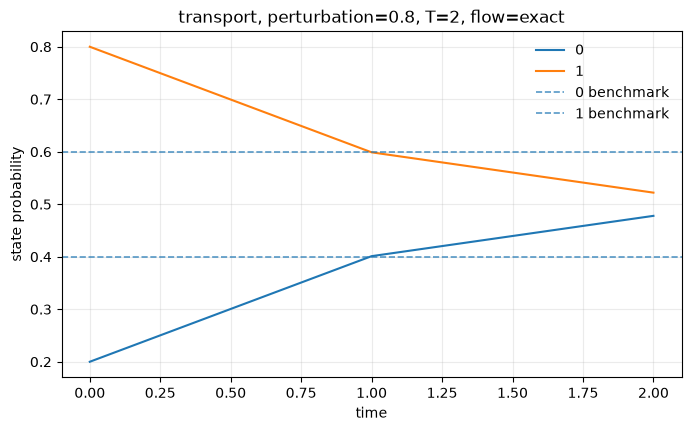

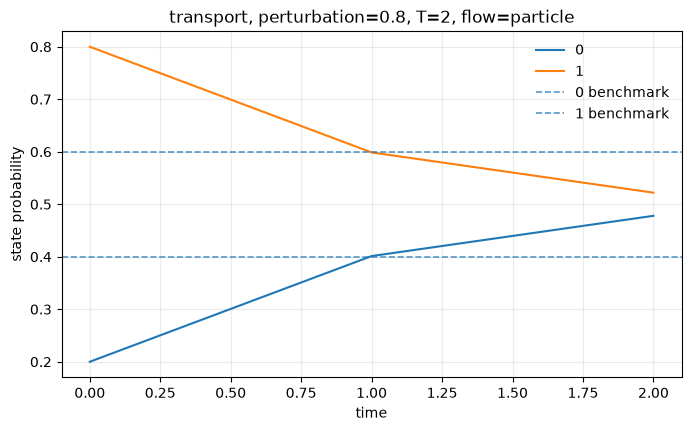

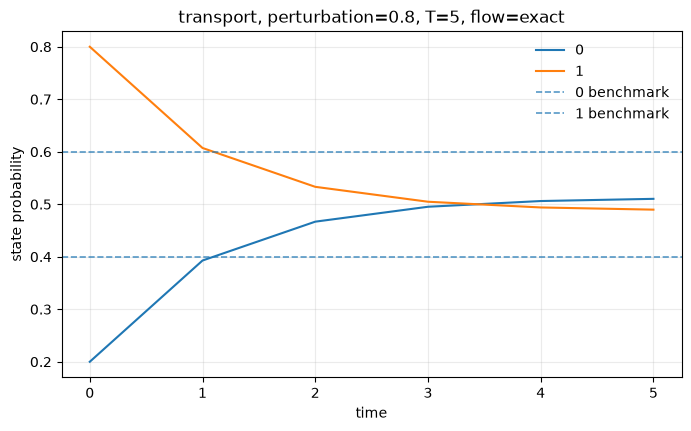

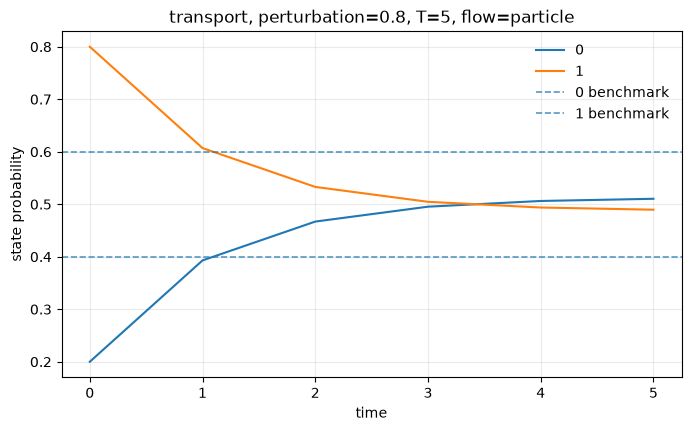

In [4]:
for run in best_runs_by_label(runs):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_state_flow(run, ax=ax)
    meta = run['metadata']
    ax.set_title(f"{meta['algorithm']}, perturbation={meta['perturbation']}, T={meta['horizon']}, flow={meta['flow']}")
    plt.show()

## Exact vs Particle Flow

Transport validation curves split by flow estimator. This highlights how much the learned behavior changes when the population flow is estimated with particles.

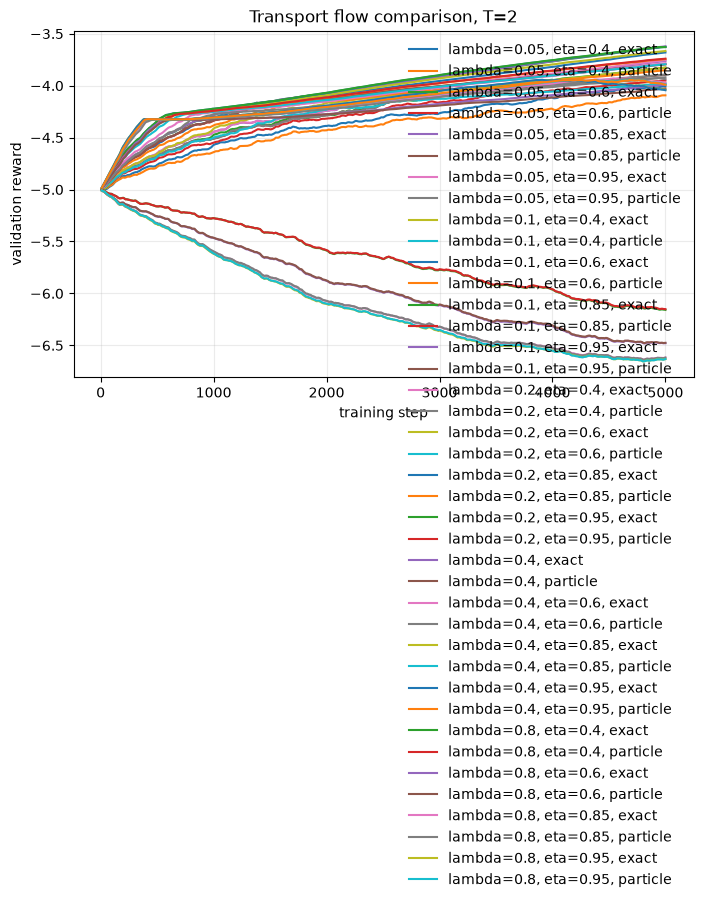

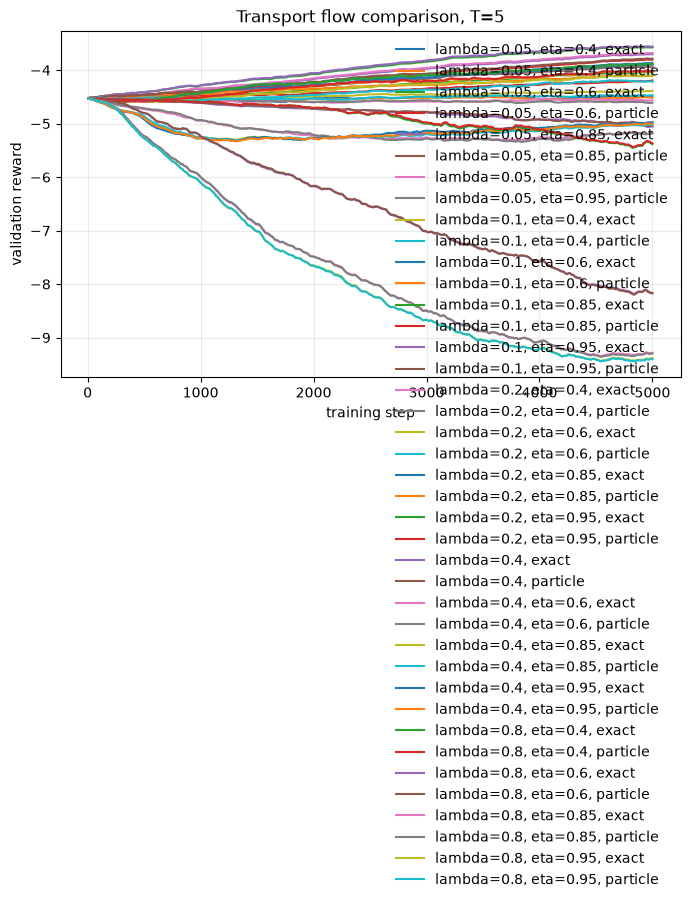

In [5]:
if runs:
    for horizon in sorted({run['metadata']['horizon'] for run in runs}):
        fig, ax = plt.subplots(figsize=(8, 4.5))
        try:
            plot_flow_comparison(runs, env=ENV, horizon=horizon, ax=ax)
            ax.set_title(f'Transport flow comparison, T={horizon}')
            plt.show()
        except ValueError as exc:
            plt.close(fig)
            print(exc)

## Objective and Runtime Tables

Summary tables for final validation reward, estimated simulator budget, and runtime. Exact objective columns appear only for environments exposing a closed-form oracle.

In [6]:
display(objective_table(runs))
display(runtime_table(runs))

,env,label,flow,horizon,eta,seed,validation_reward
0,twostate,"Adaptive transport lambda0=0.2, eta0=0.8",exact,2,0.923046,0,-3.854298
1,twostate,"Adaptive transport lambda0=0.2, eta0=0.8",exact,2,0.948399,1,-3.883503
2,twostate,"Adaptive transport lambda0=0.2, eta0=0.8",exact,2,0.915944,2,-3.762154
3,twostate,"Adaptive transport lambda0=0.2, eta0=0.8",exact,2,0.920596,3,-3.990469
4,twostate,"Adaptive transport lambda0=0.2, eta0=0.8",exact,2,0.940254,4,-3.933307
...,...,...,...,...,...,...,...
445,twostate,"Transport lambda=0.8, eta=0.95",particle,5,0.950000,0,-9.338718
446,twostate,"Transport lambda=0.8, eta=0.95",particle,5,0.950000,1,-8.882954
447,twostate,"Transport lambda=0.8, eta=0.95",particle,5,0.950000,2,-9.598873
448,twostate,"Transport lambda=0.8, eta=0.95",particle,5,0.950000,3,-9.755443


,env,algorithm,perturbation,eta,horizon,flow,setup_seconds_mean,setup_seconds_std,train_step_seconds_mean,train_step_seconds_std,validation_seconds_mean,validation_seconds_std,elapsed_seconds_mean,elapsed_seconds_std,seconds_per_step_mean,wall_seconds_per_step_mean,validation_seconds_per_call_mean,simulator_budget_mean,n_runs
0,twostate,adaptive_transport,0.2,NaN,2,exact,10.825131,0.756505,33.779907,0.261337,0.766325,0.024126,45.389103,0.755557,0.006756,0.009078,0.001533,457.92,5
1,twostate,adaptive_transport,0.2,NaN,2,particle,10.128723,0.385396,32.012783,0.368031,0.710098,0.014675,42.866104,0.549292,0.006403,0.008573,0.001420,857.92,5
2,twostate,adaptive_transport,0.2,NaN,5,exact,9.637785,0.377641,87.424119,0.799264,1.742661,0.050613,98.819799,0.883663,0.017485,0.019764,0.003485,1296.00,5
3,twostate,adaptive_transport,0.2,NaN,5,particle,9.908093,0.156868,87.643201,0.499534,1.721282,0.031537,99.287943,0.394485,0.017529,0.019858,0.003443,2296.00,5
4,twostate,mfreinforce,0.2,0.20,2,exact,20.231166,8.899733,31.847649,1.080429,0.708034,0.040646,52.801549,7.785374,0.006370,0.010560,0.001416,460.00,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,twostate,transport,0.8,0.85,5,particle,8.553428,0.494510,81.610609,0.914129,1.721251,0.057586,91.904485,1.039691,0.016322,0.018381,0.003443,2300.00,5
86,twostate,transport,0.8,0.95,2,exact,11.947942,0.333744,31.348072,0.425853,0.772244,0.045923,44.088451,0.694175,0.006270,0.008818,0.001544,460.00,5
87,twostate,transport,0.8,0.95,2,particle,9.066194,0.907546,29.472709,0.228611,0.700683,0.018051,39.253607,1.002978,0.005895,0.007851,0.001401,860.00,5
88,twostate,transport,0.8,0.95,5,exact,9.853179,0.525498,81.882486,0.533672,1.746627,0.030788,93.499909,0.937161,0.016376,0.018700,0.003493,1300.00,5
